# Portugal Housing Price Prediction
## Advanced supervised learning and deployment

- **Author:** Hussein Loubani
- **Dataset:** Real Estate Listings in Portugal (Kaggle)
- **Target:** `price` (continuous, asking price in Euros)
- **Task type:** Regression (predictive modeling) with cloud deployment

---

### Table of contents

1. Imports and setup
2. Problem definition
3. Data loading and first audit
4. Data cleaning
5. Train / test split
6. Exploratory data analysis
7. Statistical inference
8. Preprocessing strategy
9. Baseline models
10. Model comparison with cross-validation
11. Hyperparameter tuning
12. Ensemble methods
13. Final test evaluation
14. Error analysis and interpretation
15. Deployment
16. Dashboard
17. Conclusion, limitations, and recommendations

---
## 1. Imports and setup


In [1]:
# Standard library
from pathlib import Path
import warnings

# Suppress noisy sklearn UserWarnings during GridSearchCV
warnings.filterwarnings("ignore", category=UserWarning)

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

# sklearn
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, HistGradientBoostingRegressor,
    VotingRegressor, StackingRegressor,
)
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib

# Project package, installed editable (pip install -e .), so no path hacks
from portugal_housing.config import *
from portugal_housing.dataset import *
from portugal_housing.features import *
from portugal_housing.plots import *
from portugal_housing.statistics import *
from portugal_housing.modeling.train import cv_compare
from portugal_housing.modeling.predict import evaluate_model, compare_final_metrics

# Apply project-wide plot style
apply_global_style()

# Paths
DATA_PATH   = Path.cwd().parent / "data" / "raw" / "portugal_listinigs.csv"
FIG_DIR     = Path.cwd().parent / "reports" / "figures"

---
## 2. Problem definition

### Business context:

Portugal Real Estate Brokers want a model that flags underpriced listings. When the predicted price is meaningfully above the asking price, a broker reaches out to the owner about a possible purchase. The model is meant to run as an automated API, called whenever a new listing appears on the platforms the firm scrapes.

The target here is the *asking* price on a listing, not the price the property eventually sells for. Predictions reflect how sellers price their listings in this dataset, not true market value. Sale-price prediction would need transaction data we do not have.

### Machine learning formulation

| | |
|---|---|
| **Problem type** | Regression |
| **Target** | `price` (asking price in Euros, continuous) |
| **Features** | 12 property attributes: area and living area, rooms, bathrooms, parking, construction year, elevator, district, city, town, type, energy certificate |
| **Primary metric** | RMSE: reported in euros, penalizes large misses heavily |
| **Secondary metrics** | MAE, R², MAPE |
| **Baseline** | Mean predictor (DummyRegressor) and linear regression |

### Why RMSE?

RMSE is the primary metric because it is denominated in euros, the same unit as the target, so a score reads directly as "typical error, in €". It also penalizes large errors more than small ones, which matches the business cost: badly mispricing an expensive property is worse than being slightly off on a cheap one. MAE sits alongside it as a more outlier-tolerant view of the typical error, R² reports the share of price variance explained, and MAPE gives a percentage error that is comparable across price bands.

---
## 3. Data loading and first audit


### 3.1 Load data

In [2]:
df = load_data(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: 135,536 rows × 25 columns


,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,780000.0,Vila Real,Valpaços,Carrazedo de Montenegro e Curros,Farm,NC,200.0,552450.0,0.0,False,...,False,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,0.0
1,223000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,81.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,81.0,NaN,NaN,2.0
2,228000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,108.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,108.0,NaN,NaN,2.0
3,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,0.0
4,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0


### 3.2 Variable glossary

| Column | Type | Description |
|--------|------|-------------|
| Price | float | Asking price in Euros (target) |
| District | str | Administrative district (e.g., Lisboa, Porto) |
| City | str | City name |
| Town | str | Town / parish name |
| Type | str | Property type (Apartment, House, Land, etc.) |
| EnergyCertificate | str | Energy efficiency rating (A+ to F, NC) |
| TotalArea | float | Total area (m²) |
| Parking | float | Number of parking spaces |
| Elevator | bool | Whether building has an elevator |
| ConstructionYear | float | Year the property was built |
| TotalRooms | float | Total number of rooms |
| LivingArea | float | Livable space (m²) |
| NumberOfBathrooms | float | Number of bathrooms |

*Twelve high-missingness columns (GrossArea, Floor, PublishDate, BuiltArea, ConservationStatus, LotSize, NumberOfBedrooms, NumberOfWC, EnergyEfficiencyLevel, Garage, and ElectricCarsCharging are above 50% missing; HasParking sits just under at 49.7% and duplicates Parking) are documented in the data dictionary but will be dropped during cleaning.*

### 3.3 Audit data

In [3]:
summary = audit_data(df)
summary

Shape          : 135,536 rows × 25 columns
Duplicated rows: 8,913

Missing values detected:
                       missing_count  missing_%
ConservationStatus            116244      85.77
BuiltArea                     108919      80.36
GrossArea                     107898      79.61
Floor                         107607      79.39
PublishDate                   106297      78.43
LotSize                        95953      70.80
NumberOfBedrooms               88495      65.29
NumberOfWC                     78280      57.76
EnergyEfficiencyLevel          68247      50.35
Garage                         68247      50.35
ElectricCarsCharging           68247      50.35
HasParking                     67321      49.67
TotalRooms                     62292      45.96
ConstructionYear               47515      35.06
LivingArea                     30584      22.57
TotalArea                       8383       6.19
NumberOfBathrooms               6836       5.04
Price                            300       0

,dtype,n_unique,missing,missing_%,min,max,mean,median
column,,,,,,,,
Price,float64,4754,300,0.2,1.0,1380000000.0,368137.45,210000.0
District,object,27,0,0.0,N/A,N/A,N/A,N/A
City,object,275,0,0.0,N/A,N/A,N/A,N/A
Town,object,2263,2,0.0,N/A,N/A,N/A,N/A
Type,object,21,16,0.0,N/A,N/A,N/A,N/A
EnergyCertificate,object,12,14,0.0,N/A,N/A,N/A,N/A
GrossArea,float64,2267,107898,79.6,-7.0,12750000.0,2789.73,164.0
TotalArea,float64,7305,8383,6.2,-7196067.0,61420071105.0,514077.99,159.0
Parking,float64,4,194,0.1,0.0,3.0,0.55,0.0


In [4]:
print("Categorical feature value counts:")
inspect_categoricals(df, ["Type", "EnergyCertificate", "District", "City", "Town", "Elevator"])

Categorical feature value counts:
  Type                      -> {'Apartment': 47378, 'House': 36736, 'Land': 31843, 'Store': 5333, 'Farm': 3889}  (+16 more)
  EnergyCertificate         -> {'NC': 61387, 'C': 16364, 'D': 15576, 'E': 10898, 'A': 9910}  (+7 more)
  District                  -> {'Lisboa': 31351, 'Porto': 22681, 'Setúbal': 11579, 'Braga': 11445, 'Faro': 8943}  (+22 more)
  City                      -> {'Lisboa': 8396, 'Sintra': 5527, 'Porto': 5446, 'Vila Nova de Gaia': 4281, 'Cascais': 3236}  (+270 more)
  Town                      -> {'Paranhos': 2228, 'Cascais e Estoril': 1459, 'Albufeira e Olhos de Água': 1433, 'Cedofeita, Santo Ildefonso, Sé, Miragaia, São Nicolau e Vitória': 1069, 'Portimão': 1054}  (+2258 more)
  Elevator                  -> {False: 102567, True: 32937}


In [5]:
print("Target variable statistics:")
target_stats(df, target="Price")

Target variable statistics:


,count,mean,median,std,min,max,skew,kurtosis
Price,135236,368137.45,210000.0,3804044.27,1.0,1.380000e+09,352.81,127935.61


### 3.4 Numeric outlier check

In [6]:
print("Numeric outlier check (raw columns):")
anomaly_screen(df, ["Price", "TotalArea", "LivingArea", "Parking", "ConstructionYear", "TotalRooms", "NumberOfBathrooms"])

Numeric outlier check (raw columns):


,Q1,Q3,IQR,lower_fence,upper_fence,n_flagged,pct_flagged,note
feature,,,,,,,,
Price,84000.0,395000.0,311000.0,-382500.0,861500.0,10589,7.8,potential anomalies
TotalArea,91.0,500.0,409.0,-522.5,1113.5,21553,17.0,potential anomalies
LivingArea,80.0,204.0,124.0,-106.0,390.0,11967,11.4,potential anomalies
Parking,0.0,1.0,1.0,-1.5,2.5,7282,5.4,potential anomalies
ConstructionYear,1973.0,2009.0,36.0,1919.0,2063.0,361,0.4,potential anomalies
TotalRooms,2.0,4.0,2.0,-1.0,7.0,2893,3.9,potential anomalies
NumberOfBathrooms,0.0,2.0,2.0,-3.0,5.0,2743,2.1,potential anomalies


### 3.5 Audit findings

A few things stand out from the first pass over the raw file.

- Missingness is severe: 11 columns are above 50% missing, and `HasParking` sits just under at 49.7% while duplicating the Parking column, so all 12 get dropped during cleaning. Of the columns kept, the worst are `TotalRooms` (46.0%), `ConstructionYear` (35.1%), `LivingArea` (22.6%), and `NumberOfBathrooms` (5.0%).
- Mixed-type warnings on columns like `HasParking` and `Floor` are typical of a scraped feed where different sources used slightly different conventions.
- Duplicates exist and are removed in Section 4.
- The price column ranges from €1 to €1.38B. Both ends are listing artifacts rather than real properties, so we trim them.
- Price is heavily right-skewed (skew ≈ 353 in the raw data, driven by a handful of absurd entries), which is why the cleaning trims the extremes, the EDA looks at log-price, and Section 10 tests a log-transformed target head-to-head against the raw one.
- `City` (275 values) and `Town` (2,263 values) are high-cardinality. A naive one-hot encoding would blow up the feature space, but Section 8 keeps both anyway: rare levels are pooled by the encoder's frequency threshold, and the held-out results show the location signal is worth far more than the extra columns cost.

---
## 4. Data cleaning


In [7]:
raw_df = df.copy()
duplicate_summary(raw_df)

Original  : 135,536 rows × 25 columns
Unique    : 126,623 rows
Duplicates: 8,913 rows (6.6%)


### 4.1 Duplicate impact assessment

Before dropping the duplicate rows, the same check Sprint 1 used: are the duplicates a random slice of the data, or a biased subset whose removal would shift the distributions? Columns are renamed to snake_case first so the feature lists line up, then each numerical feature is compared between unique and duplicate rows with a Mann-Whitney U test, and each categorical feature with a chi-square test.

In [8]:
from portugal_housing.config import RENAME_COLS

dup_check = raw_df.rename(columns=RENAME_COLS)
print("Numerical feature impact (unique records vs extra duplicate rows):")
duplicate_impact_numerical(dup_check)

Numerical feature impact (unique records vs extra duplicate rows):


,mean (all),mean (dedup),mean Δ%,median (all),median (dedup),median Δ%,p (Mann-Whitney),sig (α=0.05)
feature,,,,,,,,
total_area,514077.99,549880.60,6.96,159.0,159.0,0.00,0.0000,Yes
parking,0.55,0.54,-1.82,0.0,0.0,0.00,0.0000,Yes
construction_year,1989.30,1988.80,-0.03,1994.0,1993.0,-0.05,0.0000,Yes
total_rooms,3.23,3.24,0.31,3.0,3.0,0.00,0.0001,Yes
living_area,1403.04,1441.44,2.74,118.0,118.0,0.00,0.3122,No
number_of_bathrooms,1.54,1.54,0.00,1.0,1.0,0.00,0.9816,No


In [9]:
print("Categorical feature impact (unique records vs extra duplicate rows):")
duplicate_impact_categorical(dup_check)

Categorical feature impact (unique records vs extra duplicate rows):


,chi2,p-value,max prop. shift,sig (α=0.05)
feature,,,,
district,2560.048,0.0,0.49,Yes
type,355.328,0.0,0.21,Yes
energy_certificate,1746.915,0.0,0.69,Yes
elevator,155.797,0.0,0.39,Yes


The duplicate rows are about 6.6% of the data. Where a test does flag a significant difference, the practical shift in means and proportions is small. Dropping the duplicates does not meaningfully move the feature distributions, so it is safe and is folded into the cleaning pipeline below.

### 4.2 Cleaning pipeline

The `clean_data()` function runs eight steps, in order:

1. Drops the 12 high-missingness columns (11 are above 50% missing; HasParking sits at 49.7% and duplicates the parking count).
2. Renames everything to snake_case.
3. Removes rows where price is missing or non-positive.
4. Keeps residential property types only (Apartment, House, Duplex, Studio, Mansion, Manor).
5. Area sanity: negative areas become NaN, living area cannot exceed total area, and total area must be at least 16 m².
6. Trims prices outside the 1st and 99.5th percentiles.
7. Price-per-m² sanity: keeps listings between €100 and €30,000 per m² where area is known, which removes data-entry errors.
8. Drops duplicate rows.

Every step targets scrape artifacts or out-of-scope listings rather than real signal. The residential filter and the area/price-per-m² checks are scoping decisions, explained next.

In [10]:
df = clean_data(df)

Cleaned dataset : 64,905 rows × 13 columns
Rows removed    : 70,631
Median price    : €275,000
Mean price      : €387,726


In [11]:
print("Property type distribution after cleaning:")
print(df["type"].value_counts().to_string())

Property type distribution after cleaning:
type
Apartment    37775
House        26752
Duplex         304
Studio          53
Mansion         18
Manor            3


### 4.3 Property type assessment

The raw data has 21 property types, but the business case is brokers buying homes, so the model is restricted to **residential** types: Apartment, House, Duplex, Studio, Mansion, Manor. That removes Land, Garage, Store, Farm, Building, Warehouse, Office, and the rest.

This is a deliberate scoping choice, not just cleanup. Mixing a €9k garage, a 25,000 m² land plot, and a city apartment in one model forces it to span wildly different price regimes and dilutes the signal for each. Restricting to residential, together with the area and price-per-m² sanity checks above, cut the data from roughly 135k rows to about 65k, but it lifted held-out R² from about 0.61 (all types, basic cleaning) to roughly 0.72 and dropped RMSE from about €264k to about €201k. Fewer, cleaner, on-scope rows beat more noisy ones here.

In [12]:
PROCESSED_PATH = Path.cwd().parent / "data" / "processed" / "portugal_housing_clean.csv"
df.to_csv(PROCESSED_PATH, index=False)
print(f"Saved cleaned data")

Saved cleaned data


---
## 5. Train / test split


In [13]:
train_df, test_df = split_data(df)

Train set : 51,924 rows  (median price: €275,000)
Test set  : 12,981 rows  (median price: €275,000)


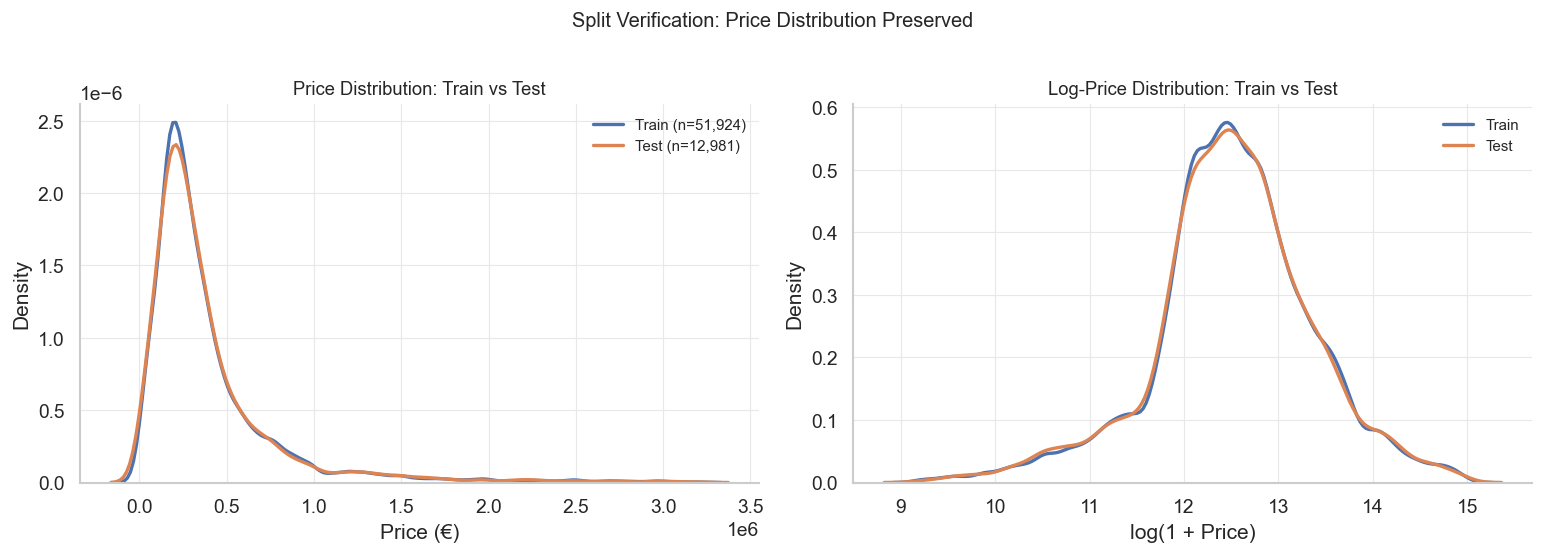

In [14]:
fig = plot_split_verification(train_df, test_df)
plt.show()
save_figure(fig, "split_verification", FIG_DIR / "train_test_split")

**Split design:**

I use a plain 80/20 random split; stratification is not needed for regression here, and the KDE overlay above confirms that the price distribution is preserved in both halves. The test set is sealed at this point, and nothing in Sections 6 to 12 (EDA, statistical inference, preprocessing, modeling, tuning, ensembling) sees it. It is only opened in Section 13 for a one-shot final evaluation.


In [15]:
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

---
## 6. Exploratory data analysis


### 6.1 Target distribution


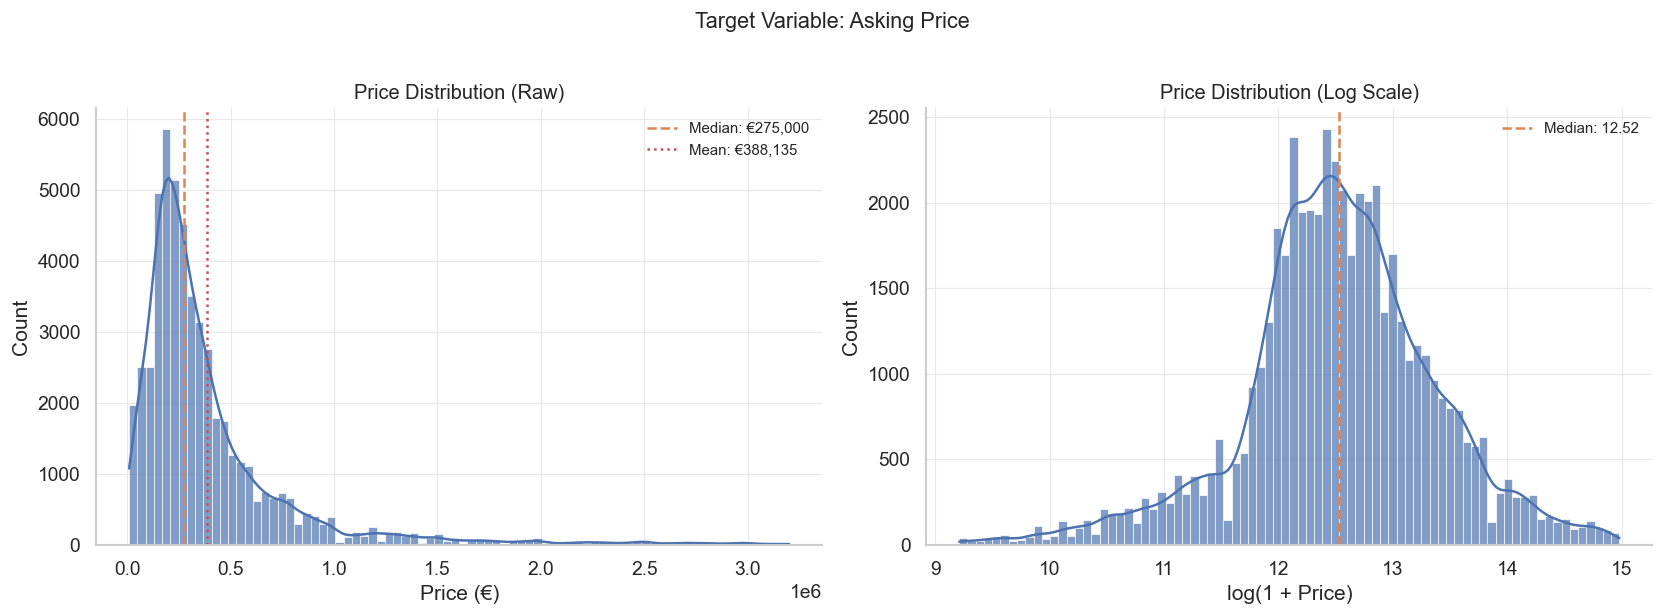

In [16]:
fig = plot_target_distribution(train_df)
plt.show()
save_figure(fig, "target_distribution", FIG_DIR / "eda")

- The raw price distribution has a long right tail. The median sits well below the mean, which is the usual signature of positive skew.
- `log(price)` is roughly normal, which means we have two reasonable options: model on the log scale, or stay on the original scale and rely on tree-based models that do not need a Gaussian target. Section 10 settles this empirically by cross-validating the same model both ways.


### 6.2 Feature distributions


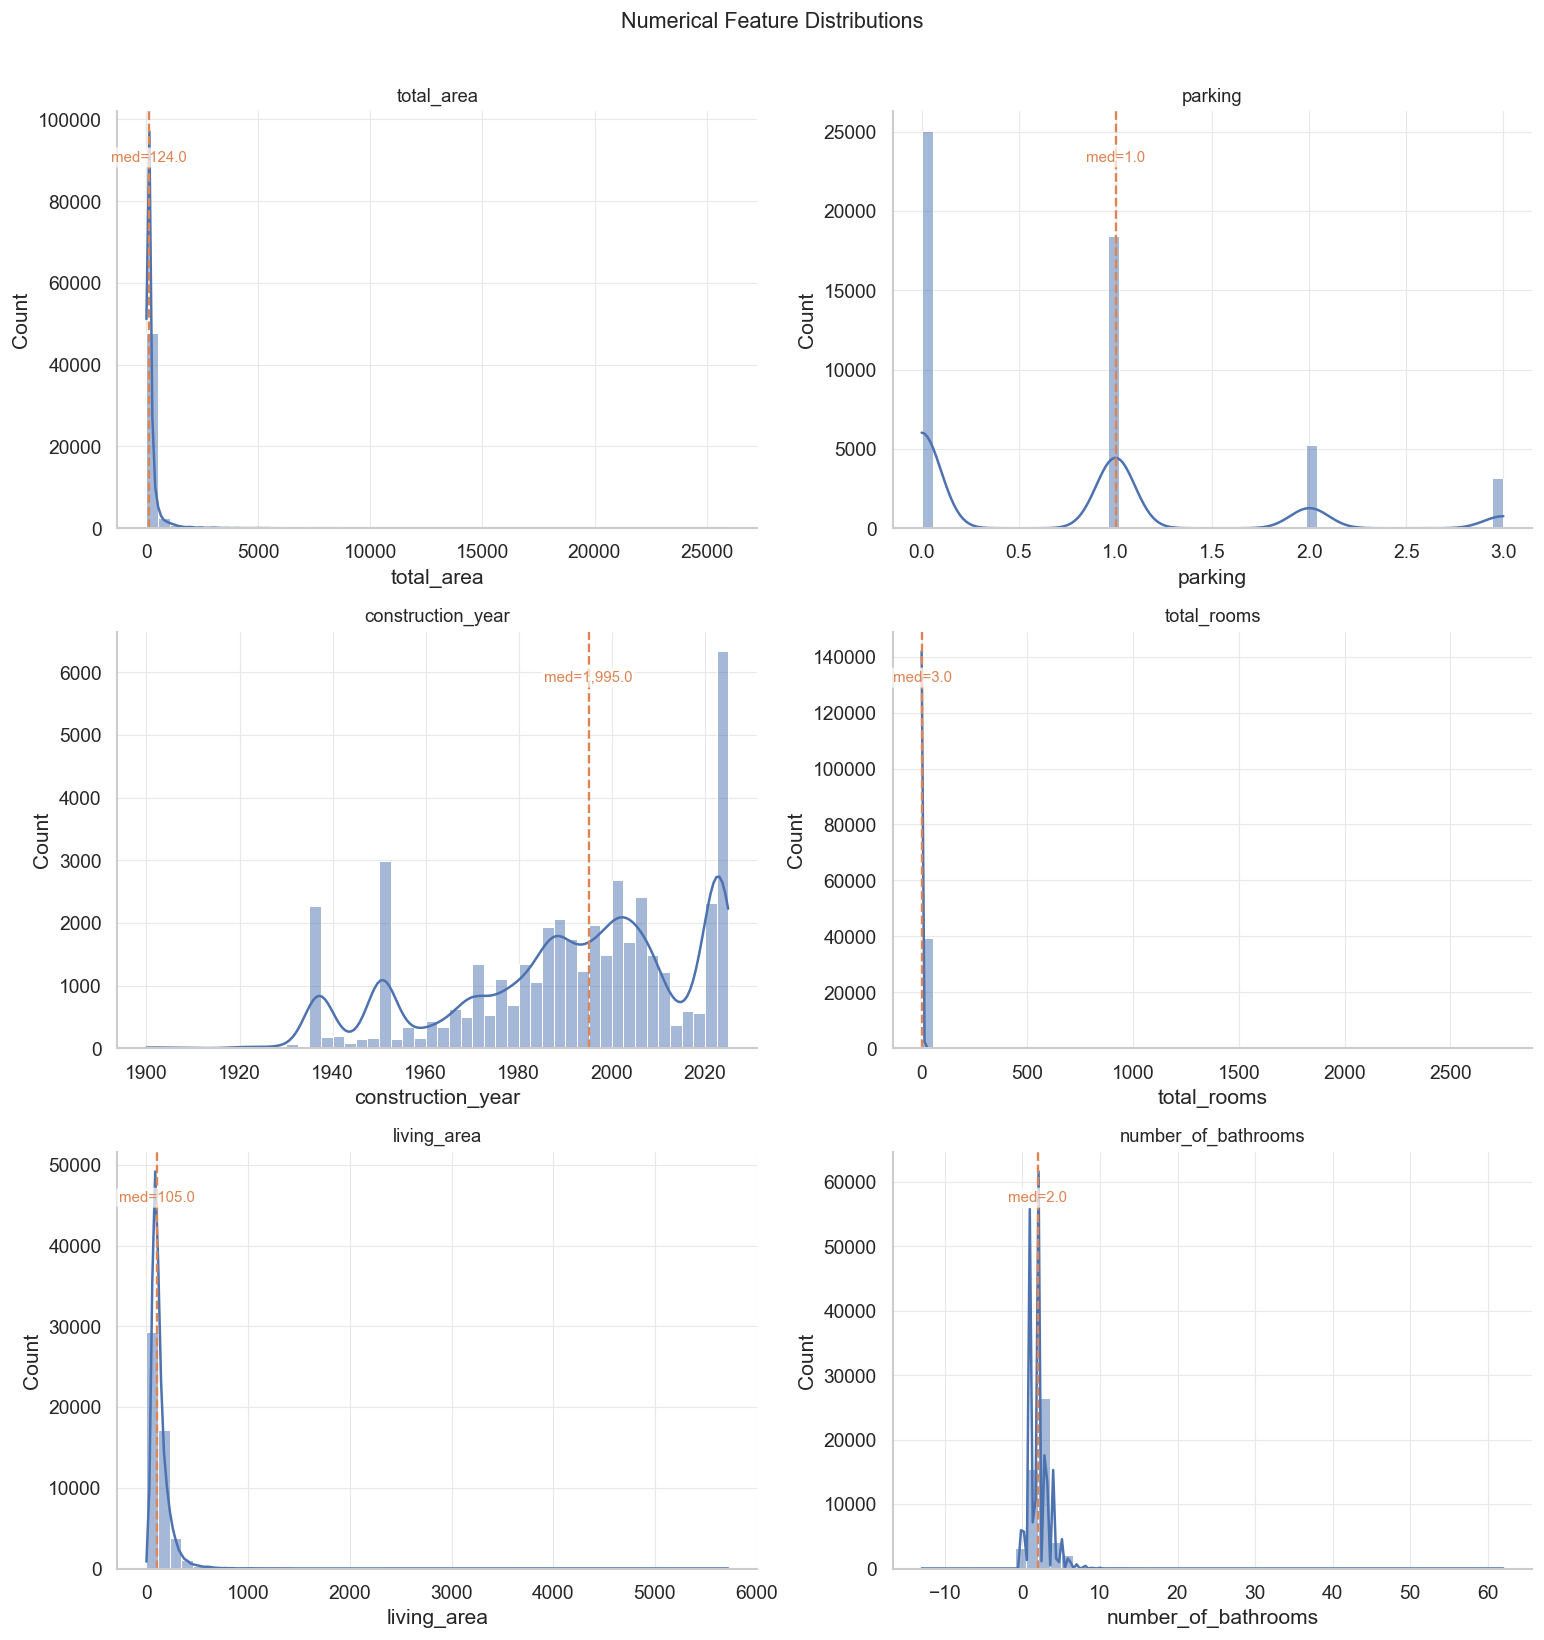

In [17]:
fig = plot_numerical_distributions(train_df, NUMERICAL_FEATURES)
plt.show()
save_figure(fig, "numerical_distributions", FIG_DIR / "eda")

- `total_area` is right-skewed. Most properties sit under 500 m² with a tail of large estates, mansions, and manor houses.
- `parking` is discrete and concentrated at 0 to 2 spaces.
- `construction_year` is bimodal, with peaks around 1970-1980 (the pre-1990 building wave) and 2010-2020 (recent development).
- `total_rooms` is right-skewed; most properties have 2 to 6 rooms.
- `living_area` looks like `total_area` but more concentrated.
- `number_of_bathrooms` is discrete, mostly 1 to 3.


### 6.3 SQL and Pandas querying

SQL handles set-level work cleanly: filtering, grouping, aggregation. Pandas is faster for row-level transforms and quick column math. I use both to show that the queries below are tool-agnostic, the choice is about which is more direct for the question.


In [18]:
con = duckdb.connect()
con.register("train", train_df)

#### Query 1 — Median price by district (SQL)

In [19]:
q1 = con.execute("""
    SELECT
        district,
        COUNT(*)                AS n,
        ROUND(MEDIAN(price), 0) AS median_price,
        ROUND(AVG(price), 0)    AS mean_price
    FROM train
    GROUP BY district
    ORDER BY median_price DESC
    LIMIT 10
""").df()
q1

,district,n,median_price,mean_price
0,Z - Fora de Portugal,7,560000.0,550714.0
1,Lisboa,15174,390000.0,558412.0
2,Faro,3544,360000.0,501725.0
3,Viseu,8,312000.0,259363.0
4,Ilha Terceira,14,307500.0,407714.0
5,Setúbal,5221,300000.0,398379.0
6,Porto,9050,290000.0,369296.0
7,Ilha de Porto Santo,3,285000.0,281667.0
8,Aveiro,2498,243000.0,290778.0
9,Braga,3963,235000.0,284288.0


#### Query 2 — Median price by property type (SQL)

In [20]:
q2 = con.execute("""
    SELECT
        type,
        COUNT(*)                AS n,
        ROUND(MEDIAN(price), 0) AS median_price,
        ROUND(AVG(total_area), 1) AS avg_area
    FROM train
    WHERE type IN ('Apartment', 'House', 'Land', 'Store', 'Farm')
    GROUP BY type
    ORDER BY median_price DESC
""").df()
q2

,type,n,median_price,avg_area
0,Apartment,30217,275000.0,136.2
1,House,21414,270000.0,392.0


#### Query 3 — Price by energy certificate (SQL)

In [21]:
q3 = con.execute("""
    SELECT
        energy_certificate,
        COUNT(*)                AS n,
        ROUND(MEDIAN(price), 0) AS median_price
    FROM train
    WHERE energy_certificate IS NOT NULL
    GROUP BY energy_certificate
    ORDER BY median_price DESC
""").df()
q3

,energy_certificate,n,median_price
0,A+,2506,440000.0
1,B,2350,435000.0
2,A,5879,435000.0
3,Not available,8,405000.0
4,B-,2029,399000.0
5,C,8514,275000.0
6,D,9355,240000.0
7,NC,11004,240000.0
8,E,6283,209000.0
9,No Certificate,25,172000.0


#### Query 4 — Price per sqm by district (Pandas)

In [22]:
train_df["price_per_sqm"] = train_df["price"] / train_df["total_area"].replace(0, np.nan)
q4 = (
    train_df.groupby("district")["price_per_sqm"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_price_per_sqm", "count": "n"})
    .sort_values("median_price_per_sqm", ascending=False)
    .head(10)
    .round(0)
)
q4

,median_price_per_sqm,n
district,,
Lisboa,3405.0,15174
Faro,2974.0,3544
Porto,2481.0,9049
Setúbal,2393.0,5220
Ilha de Porto Santo,2126.0,3
Z - Fora de Portugal,2029.0,7
Aveiro,1545.0,2492
Braga,1499.0,3959
Leiria,1477.0,2356


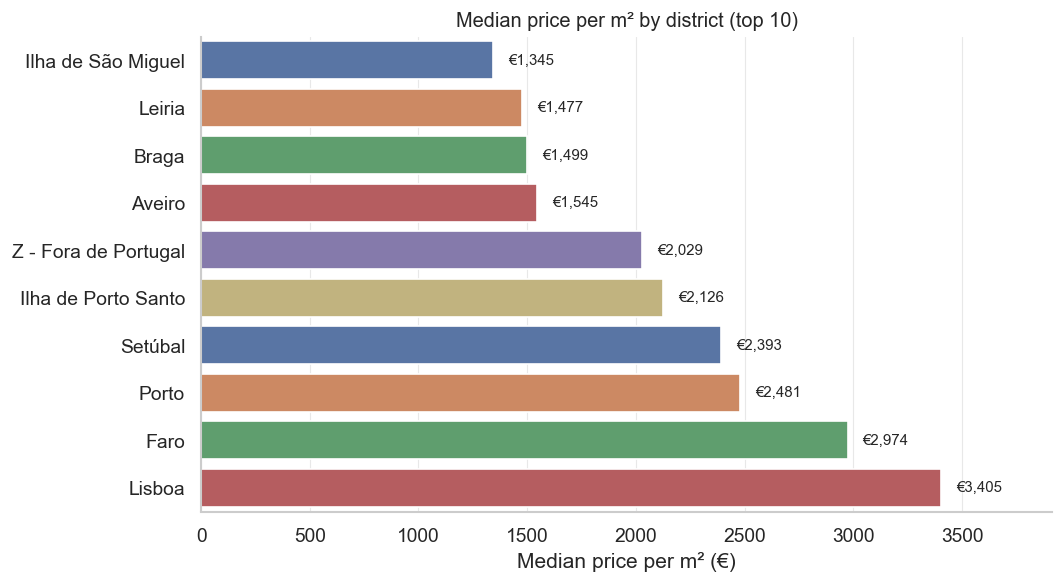

In [23]:
fig = plot_metric_by_category(
    q4["median_price_per_sqm"],
    title="Median price per m² by district (top 10)",
    xlabel="Median price per m² (€)",
)
plt.show()
save_figure(fig, "price_per_sqm_by_district", FIG_DIR / "eda")

In [24]:
train_df = train_df.drop(columns=["price_per_sqm"])

#### Query 5 — Properties with vs without elevator (Pandas)

In [25]:
q5 = (
    train_df.groupby("elevator")["price"]
    .agg(["median", "mean", "count"])
    .rename(columns={"median": "median_price", "mean": "mean_price", "count": "n"})
    .round(0)
)
q5

,median_price,mean_price,n
elevator,,,
False,238800.0,354254.0,31992
True,330000.0,442509.0,19924


### 6.4 Query findings

Five things come out of the queries:

- Geographic premium: Lisboa has the highest median prices among the real districts, with Faro and Setúbal close behind. Northern interior districts (Bragança, Vila Real) are well below.
- Property type pricing: apartments and houses are nearly tied on median asking price (€275k vs €270k), but houses are almost three times larger on average (392 m² vs 136 m²), so apartments are far ahead on price per m². That is the city-land premium showing up directly.
- Energy efficiency premium: A+, A, and B certificates carry a clear price premium over C-F and NC.
- Elevator premium: properties with elevators have substantially higher medians, almost certainly because the elevator flag is a proxy for newer construction in urban locations.
- Price per m²: Lisboa leads here too, in line with capital-city pricing pressure.

### 6.5 Feature vs. target analysis


/Users/hussein-loubani/Turing College/Module 3/Sprint 2/portugal_housing/plots.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


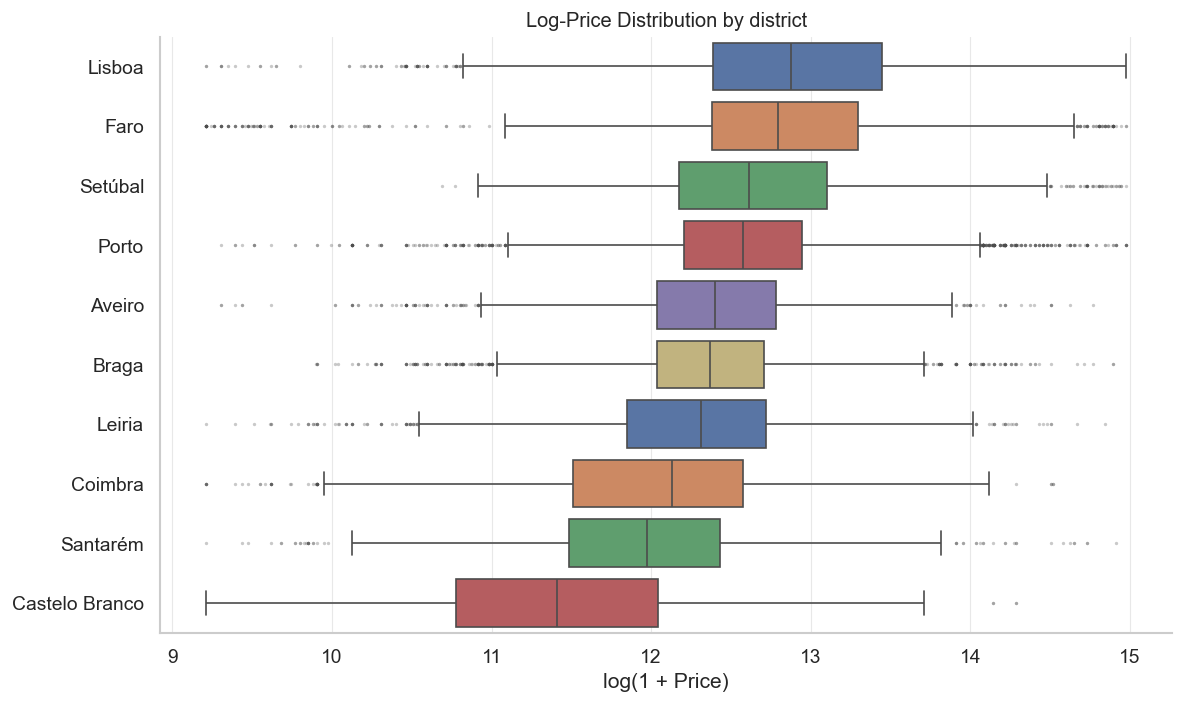

In [26]:
fig = plot_boxplots_by_category(train_df, "district", top_n=10)
plt.show()
save_figure(fig, "boxplots_by_district", FIG_DIR / "eda")

/Users/hussein-loubani/Turing College/Module 3/Sprint 2/portugal_housing/plots.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


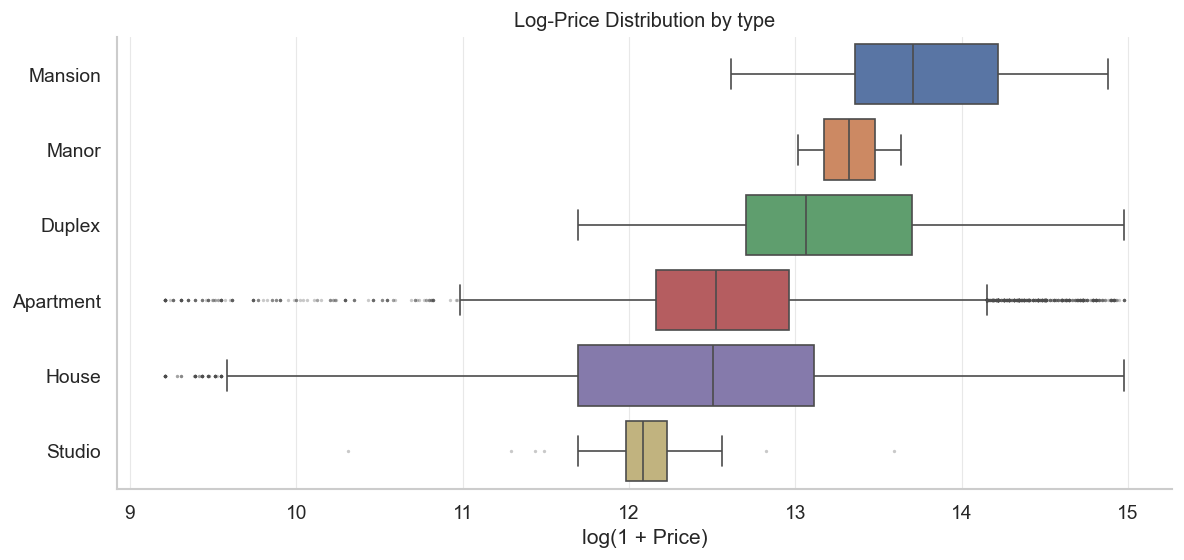

In [27]:
fig = plot_boxplots_by_category(train_df, "type", top_n=8)
plt.show()
save_figure(fig, "boxplots_by_type", FIG_DIR / "eda")

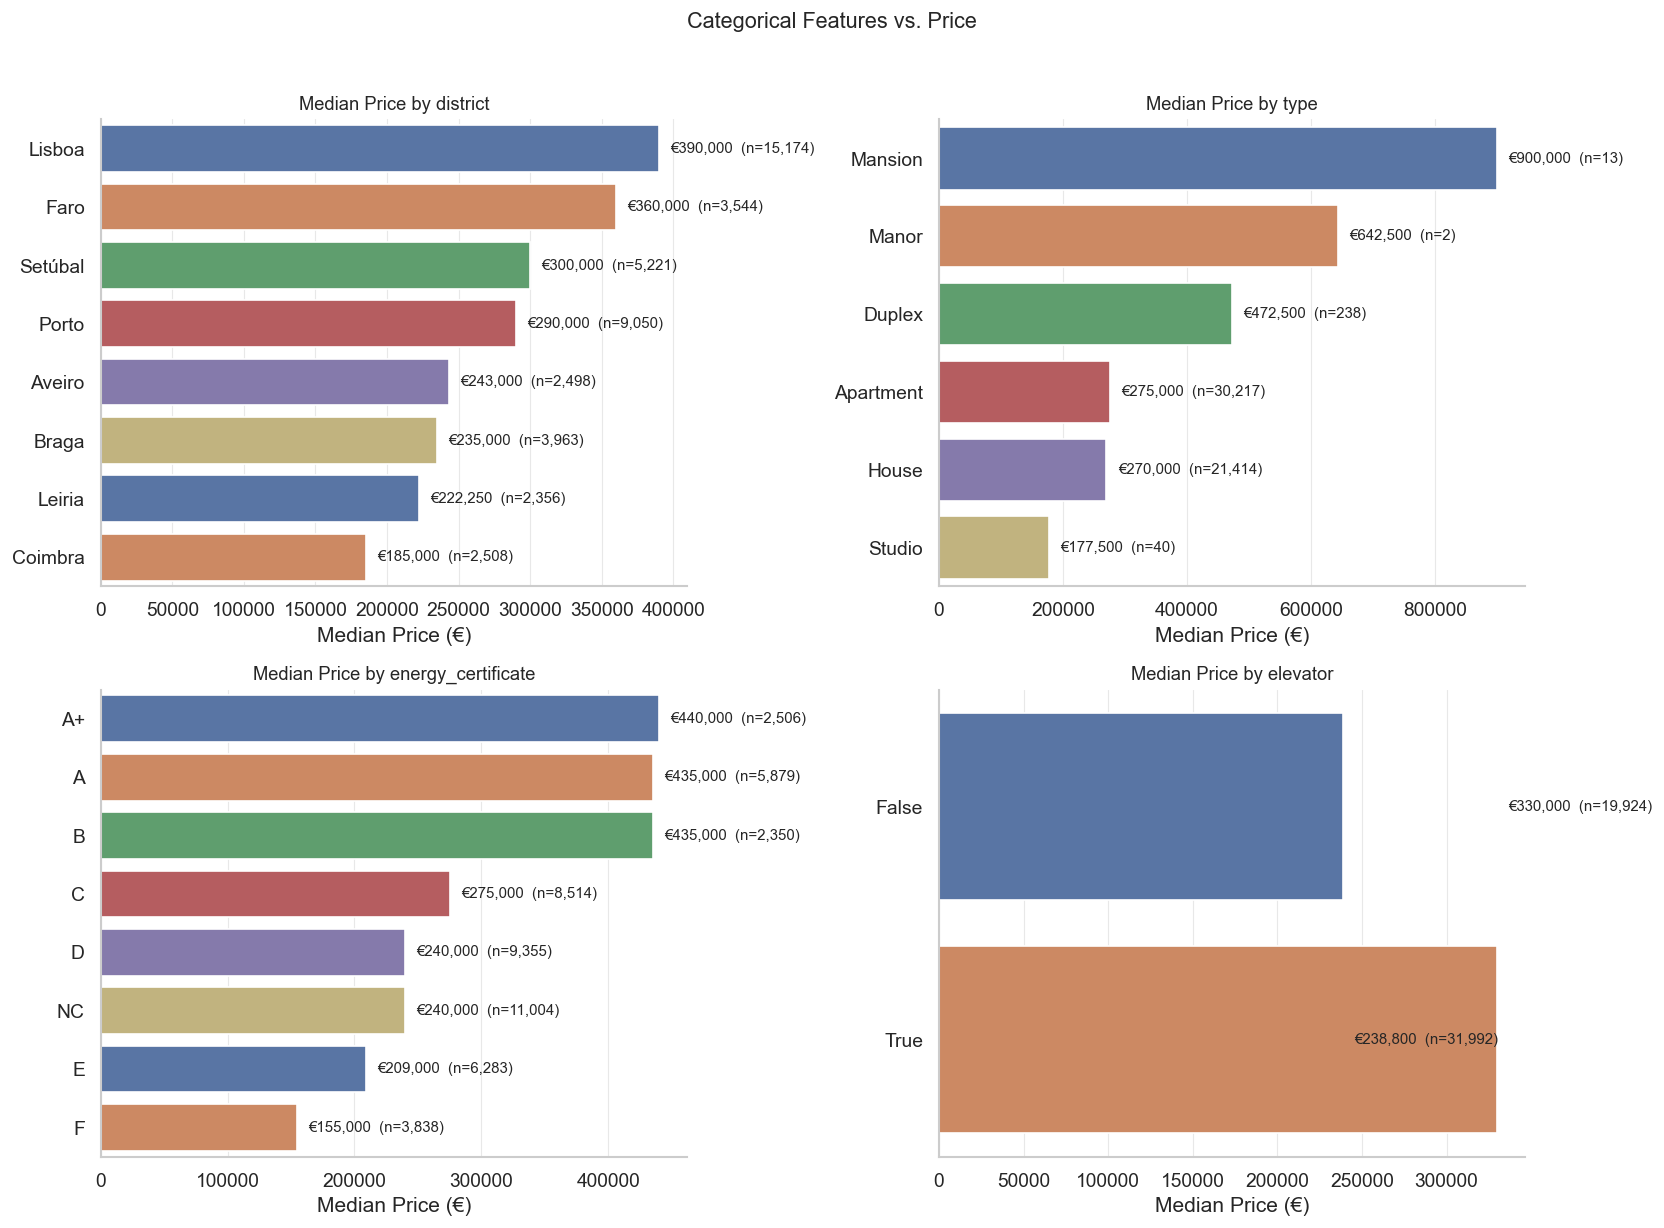

In [28]:
fig = plot_categorical_distributions(train_df, CATEGORICAL_FEATURES, top_n=8)
plt.show()
save_figure(fig, "categorical_distributions", FIG_DIR / "eda")

**Categorical findings:**

- `district` is a strong price predictor. Lisboa and Faro sit at the top of the distribution; interior districts cluster at the bottom.
- `type` still separates pricing within the residential universe: mansions and manors sit far above the rest, houses and duplexes occupy the middle, and studios sit at the bottom, which mostly tracks size.
- `energy_certificate` shows a gradient. A+, A, and B properties carry a clear premium.

### 6.6 Correlation and association


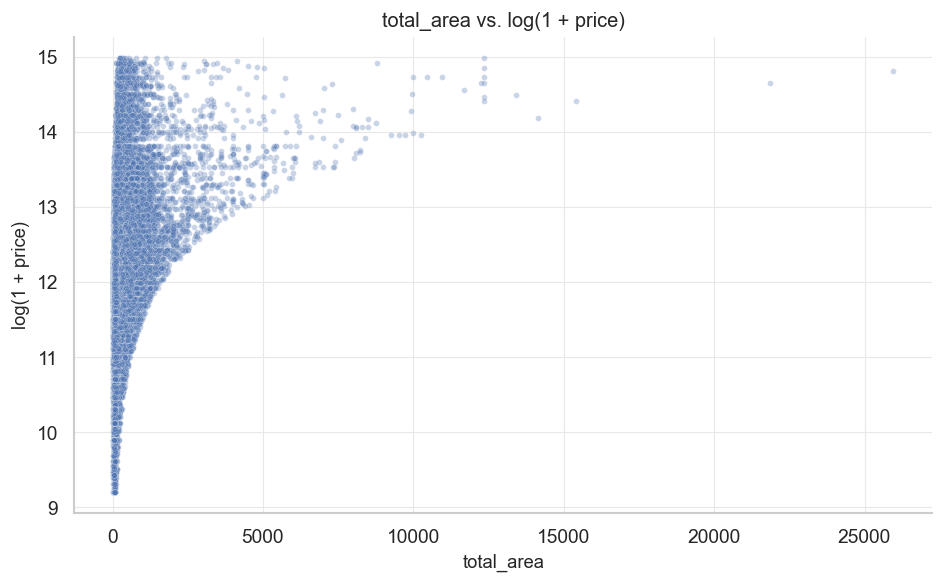

In [29]:
fig = plot_scatter(train_df, x="total_area", log_y=True)
plt.show()
save_figure(fig, "scatter_area_price", FIG_DIR / "eda")

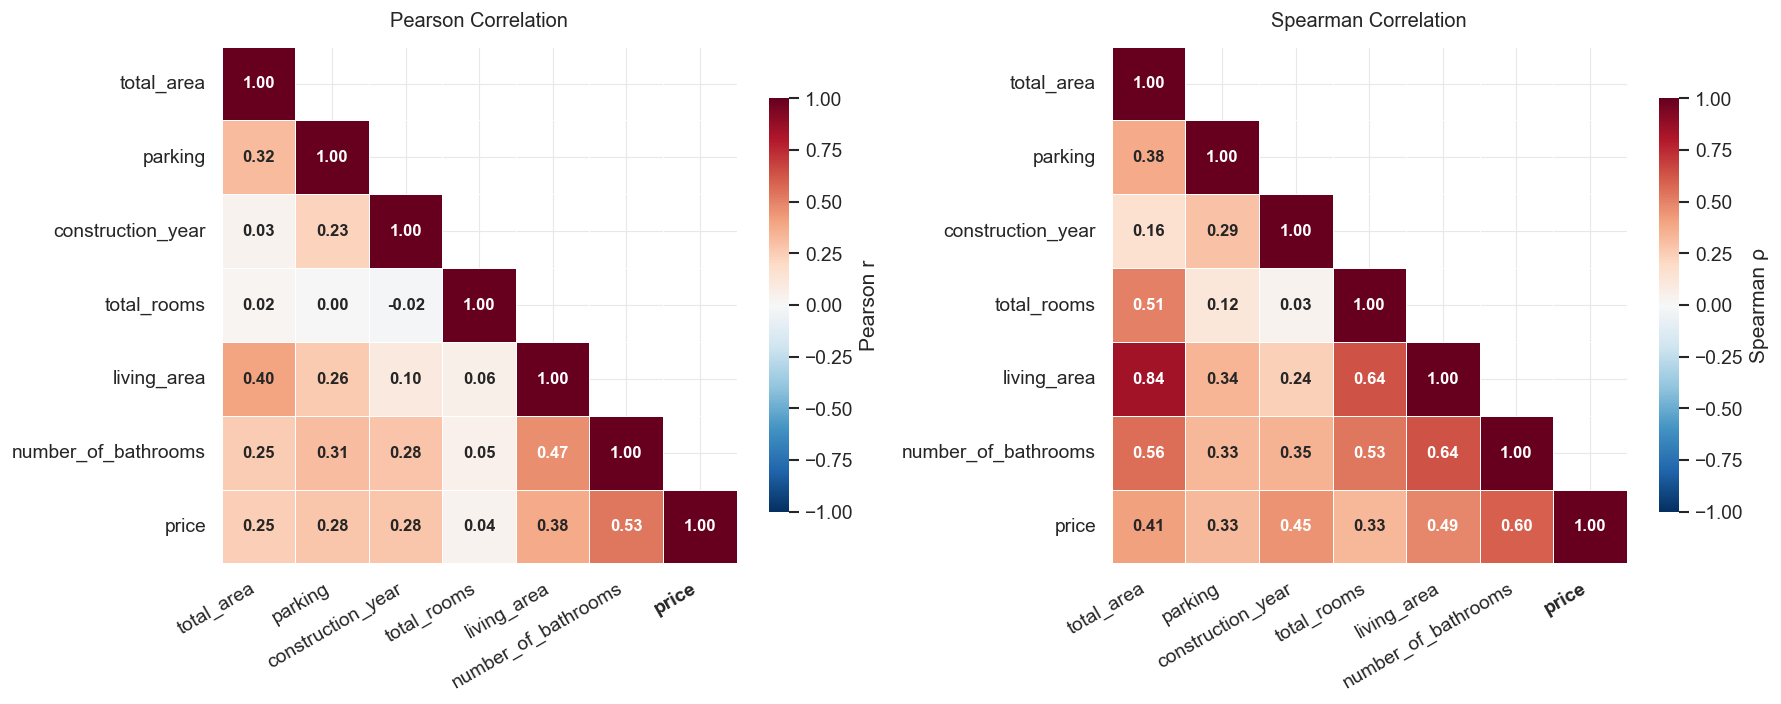

In [30]:
fig = plot_correlation_heatmap(train_df, NUMERICAL_FEATURES)
plt.show()
save_figure(fig, "correlation_heatmap", FIG_DIR / "eda")

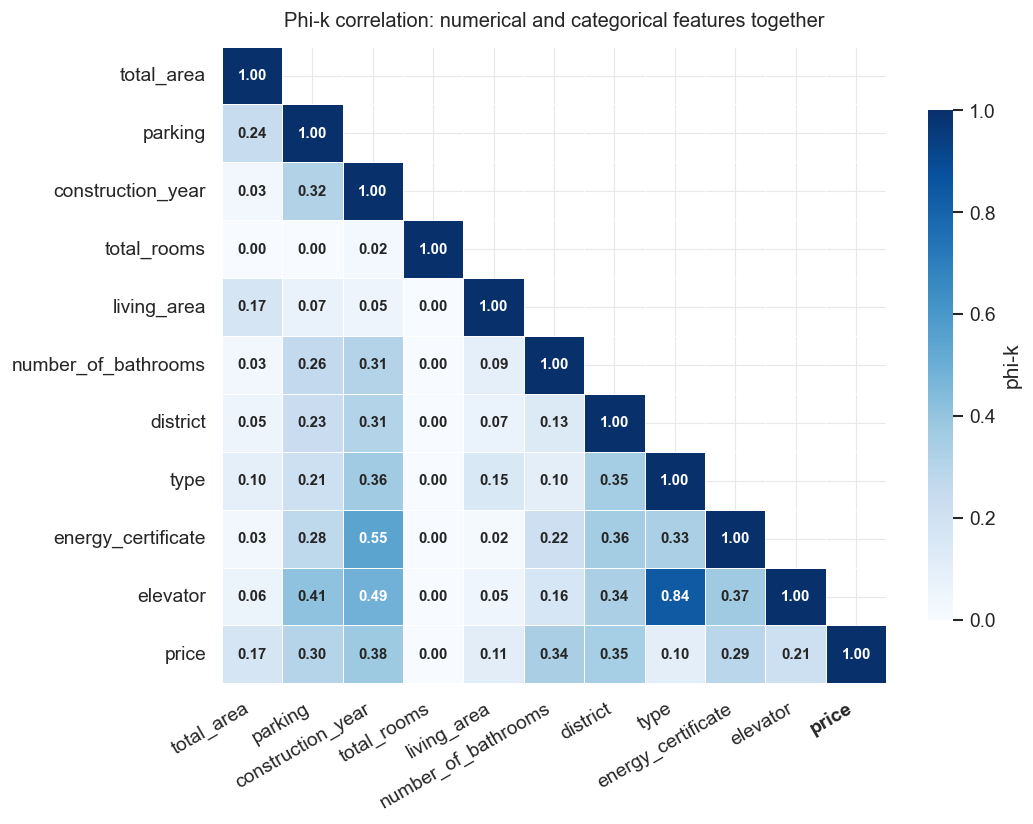

In [31]:
# Pearson and Spearman only see numeric pairs. Phi-k handles the mixed case:
# it measures association between any column types on a common 0-to-1 scale,
# so the categorical features can be compared against price directly.
fig = plot_phik_heatmap(
    train_df,
    columns=NUMERICAL_FEATURES + CATEGORICAL_FEATURES + [TARGET],
    interval_cols=NUMERICAL_FEATURES + [TARGET],
)
plt.show()
save_figure(fig, "phik_heatmap", FIG_DIR / "eda")

**Correlation and association findings:**

- `total_area` and `living_area` correlate most strongly with price under both Pearson and Spearman. Size is the primary driver of listing price, which is what we expect.
- `number_of_bathrooms` and `total_rooms` also correlate positively, which is essentially the same effect: bigger properties have more rooms.
- `total_area` and `living_area` are highly correlated with each other. Tree-based models do not care, but linear models will need either regularization or one of them dropped.
- `construction_year` shows a weak positive association. Newer properties tend to be slightly more expensive on average, but the effect is small compared to area and location.
- Pearson and Spearman are blind to the categorical columns, which is where phi-k earns its place: it puts every feature on one 0-to-1 association scale. The phi-k matrix shows the location columns (district, and especially city and town in the cleaned data) associate strongly with price, on par with the area features. That is direct evidence for the preprocessing decision in Section 8 to keep the geographic columns as model features rather than dropping them for cardinality.


---
## 7. Statistical inference


### Population and sample

**Target population:** properties listed for sale on Portuguese real estate platforms.

**Sample:** the cleaned training split, roughly 52k residential listings scraped from several Portuguese property sites. This is not a random sample of the Portuguese housing stock. It is a convenience sample of whatever was listed and successfully scraped during the collection window.

**Representativeness risks:**

1. **Listing bias:** only properties actively for sale appear. Owner-occupied homes that never reach the market are absent, and they may differ systematically in size, age, and location.
2. **Platform skew:** the source sites may over-represent certain agencies, regions, or price tiers.
3. **Asking price, not sale price:** every figure here is what a seller asked, not what a buyer paid.
4. **Snapshot in time:** the data covers a single window. Interest rates and market conditions that move prices are not captured.

**Consequence for inference:** the tests below tell us whether differences are significant *within this sample of listings*. They do not generalize to the full Portuguese housing market, and they describe associations, not causes.

---

### Hypotheses

Three hypotheses, each motivated by the EDA and the business problem. Significance level α = 0.05 for all of them.

| # | Feature | H0 | H1 | Test |
|---|---|---|---|---|
| 1 | `district` | Mean price in Lisboa = mean price elsewhere | The two differ | Welch's t-test |
| 2 | `energy_certificate` | Mean price is equal across all certificate levels | At least one level differs | One-way ANOVA |
| 3 | `type` | Mean price of apartments = mean price of houses | The two differ | Welch's t-test |

### Hypothesis 1: Lisboa properties have significantly higher prices than other districts

| | Statement |
|---|---|
| **H0** | Mean price in Lisboa = mean price in other districts |
| **H1** | Mean price in Lisboa ≠ mean price in other districts |
| **α** | 0.05 |
| **Test** | Welch's two-sample t-test |

In [32]:
lisboa = train_df[train_df["district"] == "Lisboa"]["price"]
non_lisboa = train_df[train_df["district"] != "Lisboa"]["price"]

h1_result = two_sample_ttest(
    lisboa, non_lisboa,
    feature_name="price",
    h0="Mean price in Lisboa = mean price in other districts",
    h1="Mean price in Lisboa ≠ mean price in other districts",
)
print_test_result(h1_result)

──────────────────────────────────────────────────────────────
  Feature  : price
  H0       : Mean price in Lisboa = mean price in other districts
  H1       : Mean price in Lisboa ≠ mean price in other districts
  alpha    : 0.05

  Levene p-value : 0.0  (equal variance assumed: False)
  Group 0 mean   : 558,411.51  (n=15,174)
  Group 1 mean   : 317,828.85  (n=36,750)
  Difference     : 240,582.6593
  t-statistic    : 55.9140
  p-value    : 0.000000
  95% CI     : [232148.9655, 249016.3532]

  Verdict    : REJECT H0
──────────────────────────────────────────────────────────────


The t-test gives a clear rejection of H0. The 95% confidence interval for the difference in means does not contain zero, so the gap is not a sampling artifact. Lisboa being the capital, with concentrated demand and economic activity, is the obvious story.


### Hypothesis 2: Energy certificate rating is associated with price differences

| | Statement |
|---|---|
| **H0** | Mean price is equal across all energy certificate levels |
| **H1** | At least one energy certificate level has a different mean price |
| **α** | 0.05 |
| **Test** | One-way ANOVA |

In [33]:
cert_groups = []
cert_names  = []
for cert in ["A+", "A", "B", "B-", "C", "D", "E", "F"]:
    g = train_df[train_df["energy_certificate"] == cert]["price"].dropna()
    if len(g) >= 30:
        cert_groups.append(g)
        cert_names.append(cert)

h2_result = anova_test(
    cert_groups, cert_names,
    feature_name="price",
    h0="Mean price is equal across all energy certificate levels",
    h1="At least one energy certificate level has a different mean price",
)
print_test_result(h2_result)

──────────────────────────────────────────────────────────────
  Feature  : price
  H0       : Mean price is equal across all energy certificate levels
  H1       : At least one energy certificate level has a different mean price
  alpha    : 0.05

  A+                   : mean=569,604.87  (n=2,506)
  A                    : mean=586,933.39  (n=5,879)
  B                    : mean=602,219.65  (n=2,350)
  B-                   : mean=556,516.20  (n=2,029)
  C                    : mean=395,406.22  (n=8,514)
  D                    : mean=332,622.40  (n=9,355)
  E                    : mean=284,675.50  (n=6,283)
  F                    : mean=215,919.72  (n=3,838)
  Levene p-value : 0.0  (equal variance assumed: False)
  F-statistic    : 726.7356
  p-value    : 0.000000

  Verdict    : REJECT H0
──────────────────────────────────────────────────────────────


ANOVA rejects H0 with a very small p-value. Energy certificate level is associated with significant price differences, with the efficient tiers (A+, A, B) asking the most. The premium probably reflects two things at once: the direct value of efficiency, and the fact that high ratings tend to come with newer buildings.


### Hypothesis 3: Apartments and houses have significantly different prices

| | Statement |
|---|---|
| **H0** | Mean price of apartments = mean price of houses |
| **H1** | Mean price of apartments ≠ mean price of houses |
| **α** | 0.05 |
| **Test** | Welch's two-sample t-test |

In [34]:
apt_prices   = train_df[train_df["type"] == "Apartment"]["price"]
house_prices = train_df[train_df["type"] == "House"]["price"]

h3_result = two_sample_ttest(
    apt_prices, house_prices,
    feature_name="price",
    h0="Mean price of apartments = mean price of houses",
    h1="Mean price of apartments ≠ mean price of houses",
)
print_test_result(h3_result)

──────────────────────────────────────────────────────────────
  Feature  : price
  H0       : Mean price of apartments = mean price of houses
  H1       : Mean price of apartments ≠ mean price of houses
  alpha    : 0.05

  Levene p-value : 0.0  (equal variance assumed: False)
  Group 0 mean   : 373,932.87  (n=30,217)
  Group 1 mean   : 404,853.06  (n=21,414)
  Difference     : -30,920.1920
  t-statistic    : -8.5591
  p-value    : 0.000000
  95% CI     : [-38000.8973, -23839.4867]

  Verdict    : REJECT H0
──────────────────────────────────────────────────────────────


The test rejects H0. Houses ask more on average than apartments, which mostly tracks their larger size. Once we control for area (price per m²), the relationship can flip in dense urban centers where apartment land is at a premium.


### Statistical inference findings

- **H1 — Lisboa premium (Welch's t-test):** H0 rejected. Lisboa listings ask significantly more than the rest of the country, and the 95% confidence interval for the gap excludes zero. District is confirmed as a first-order price driver.
- **H2 — Energy certificate (one-way ANOVA):** H0 rejected. Mean price differs across certificate levels, with the A+/A/B tiers well above C through F (NC was not part of the ANOVA groups; the EDA in Section 6 shows NC listings price in line with the D tier). Part of this is the efficiency itself and part is its correlation with newer construction.
- **H3 — Apartment vs house (Welch's t-test):** H0 rejected. Houses ask more on average, largely tracking their larger size. The relationship can invert on a price-per-m² basis in dense urban areas.

All three features are kept for modeling and the tests confirm they carry real signal, the models decide how much weight each one gets.

---
## 8. Preprocessing strategy


### 8.1 Feature typing and treatment plan

| Feature | Type | Treatment |
|---------|------|-----------|
| total_area | Numerical | StandardScaler |
| parking | Numerical | StandardScaler |
| construction_year | Numerical | StandardScaler |
| total_rooms | Numerical | StandardScaler |
| living_area | Numerical | StandardScaler |
| number_of_bathrooms | Numerical | StandardScaler |
| elevator | Binary | With categoricals (bool level) |
| type | Categorical (low card.) | OneHotEncoder (drop='first', min_frequency=50) |
| energy_certificate | Categorical (low card.) | OneHotEncoder (drop='first', min_frequency=50) |
| district | Categorical (medium card.) | OneHotEncoder (drop='first', min_frequency=50) |
| city | Geographic (high card., ~270 levels) | OneHotEncoder (drop='first', min_frequency=30) |
| town | Geographic (high card., ~2,300 levels) | OneHotEncoder (drop='first', min_frequency=30) |

The first version of this notebook dropped city and town for cardinality reasons. The peer review pushed back on that, and the data agrees with the reviewer: with rare levels pooled into the encoder's infrequent bucket, keeping both columns lifts held-out R² from about 0.72 to about 0.85 and cuts RMSE by roughly €50k. High cardinality turned out to be an encoding problem, not a reason to discard the strongest signal in the dataset. The `min_frequency=30` threshold keeps any town with at least 30 training listings as its own indicator and pools the long tail, which caps the one-hot matrix at a manageable width (about 565 columns) and gives unseen towns at prediction time a safe landing spot in the pooled bucket.

### 8.2 Feature engineering


In [35]:
train_eng = add_engineered_features(train_df)
print("New engineered features (first 5 rows):")
train_eng[["property_age", "log_total_area", "log_living_area"]].head()

New engineered features (first 5 rows):


,property_age,log_total_area,log_living_area
0,22.0,5.049856,4.867534
1,75.0,3.850148,3.610918
2,16.0,4.997212,4.682131
3,20.0,4.094345,4.043051
4,66.0,5.525453,5.525453


**Feature engineering notes:**

- `property_age` is the current year minus `construction_year`, computed at runtime rather than hardcoded. It captures the age effect more directly than the raw year, which is convenient for linear models. Missing construction years stay as NaN and are handled by the imputer.
- `log_total_area` and `log_living_area` use `log1p`. The transform pulls in the long tail and linearizes the area-price relationship for regression-based models.
- `price_per_sqm` was useful in EDA (Query 4) but is excluded from modeling features. It is a function of the target and would leak.


### 8.3 Preprocessing pipeline

Preprocessing is one sklearn `ColumnTransformer` wrapped in a `Pipeline` factory (`make_pipeline`). Every call returns a fresh, unfitted pipeline, which keeps cross-validation honest: the transformer is only ever fitted on the training fold.

The transformer has three blocks: scaled numericals, one-hot categoricals with `min_frequency=50` pooling, and the two geographic columns with a lower `min_frequency=30` threshold so mid-sized towns keep their own indicator instead of vanishing into the pooled bucket.


### 8.4 Dimensionality reduction


In [36]:
X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

In [37]:
pre_fitted = build_preprocessor().fit(X_train)
X_tr = pre_fitted.transform(X_train)
print(f"Preprocessed shape: {X_tr.shape}")

Preprocessed shape: (51924, 565)


In [38]:
pca = PCA().fit(X_tr)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n95 = np.argmax(cumvar >= 0.95) + 1
n99 = np.argmax(cumvar >= 0.99) + 1
print(f"Components for 95% variance: {n95}")
print(f"Components for 99% variance: {n99}")
print(f"Total components: {X_tr.shape[1]}")

Components for 95% variance: 145
Components for 99% variance: 335
Total components: 565


**PCA findings:**

PCA is here for diagnostics, not for modeling, and the number of components needed to hit 95% variance gives a sense of how much redundancy the OHE expansion introduces: 145 of 565 components carry 95% of the variance, so the one-hot blocks are highly redundant in the linear sense, which is expected when thousands of town levels pool into a few hundred sparse indicators. I do not feed PCA components into the final models. Tree-based models work directly on the sparse encoded features and gain nothing from PCA's rotation, so the full feature set goes through.


---
## 9. Baseline models


In [39]:
dummy_pipe = make_pipeline(DummyRegressor(strategy="mean"))
lr_pipe    = make_pipeline(LinearRegression())
ridge_pipe = make_pipeline(Ridge(alpha=1.0, random_state=RANDOM_SEED))
lasso_pipe = make_pipeline(Lasso(alpha=1.0, random_state=RANDOM_SEED, max_iter=5000))

baseline_pipelines = {
    "Dummy (mean)":       dummy_pipe,
    "Linear Regression":  lr_pipe,
    "Ridge":              ridge_pipe,
    "Lasso":              lasso_pipe,
}

baseline_cv = cv_compare(baseline_pipelines, X_train, y_train)
baseline_cv

,cv_neg_root_mean_squared_error_mean,cv_neg_root_mean_squared_error_std,train_score_mean,fit_time_s
model,,,,
Linear Regression,-310156.4580,153722.7320,-230701.5454,1.56
Lasso,-310161.7363,153720.2295,-230707.4824,105.15
Ridge,-310189.5682,153789.6060,-230730.9345,0.61
Dummy (mean),-383689.8069,6629.0461,-383741.3190,0.48


**Baseline findings:**

The dummy regressor (always predict the mean price) sets the floor. Anything we deploy needs to beat it by a wide margin, otherwise we are paying for compute to reproduce a one-line script. Linear Regression, Ridge, and Lasso give the linear baseline. The gap between these and the tree-based models in Section 10 tells us how much of the price signal is non-linear: a small gap means most of the signal is linear, a large gap means interactions and non-linearities matter. Here the linear trio lands around €310k CV RMSE against the dummy's €384k, so a linear fit captures real signal but leaves a lot on the table; the trees below cut that error roughly in half.


---
## 10. Model comparison with cross-validation


In [40]:
candidate_pipelines = {
    "Decision Tree":  make_pipeline(DecisionTreeRegressor(random_state=RANDOM_SEED)),
    "Random Forest":  make_pipeline(RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)),
    "HistGB":         make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_SEED)),
    "XGBoost":        make_pipeline(xgb.XGBRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)),
    "LightGBM":       make_pipeline(lgb.LGBMRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)),
}

cv_results = cv_compare(candidate_pipelines, X_train, y_train)
cv_results

,cv_neg_root_mean_squared_error_mean,cv_neg_root_mean_squared_error_std,train_score_mean,fit_time_s
model,,,,
Random Forest,-162984.7947,3801.6149,-62199.0912,53.97
XGBoost,-172911.3212,3194.9914,-134126.5774,1.71
LightGBM,-177898.2793,3128.4096,-159218.0149,1.55
HistGB,-178443.5267,3420.1248,-161226.5913,12.91
Decision Tree,-216338.2391,6239.4232,-14454.0238,1.37


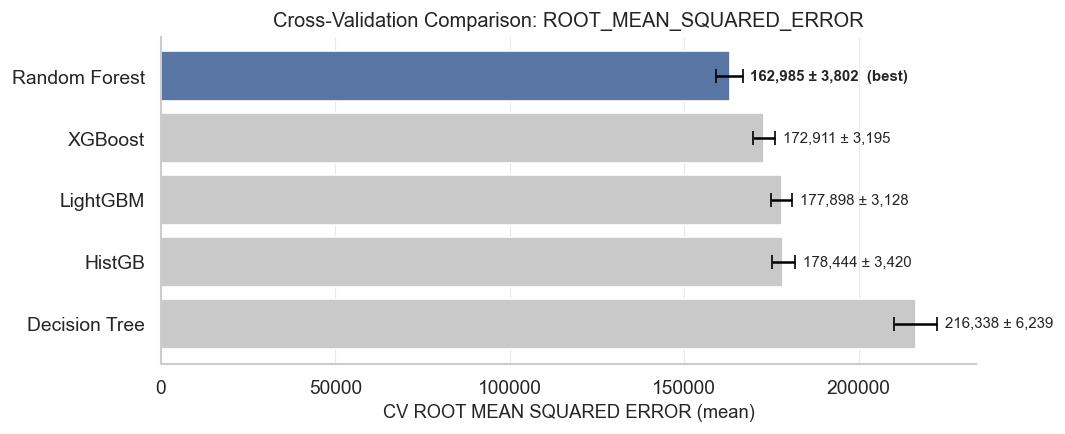

In [41]:
fig = plot_cv_comparison(cv_results)
plt.show()
save_figure(fig, "cv_comparison_baseline", FIG_DIR / "model_comparison")

**Reading the comparison:**

Mean CV RMSE is the primary ranking criterion. Lower is better, and a high standard deviation across folds is a warning that the model is unstable on this data.

What the table shows on this data:

- A single decision tree overfits hard, exactly as expected: its training error is a tiny fraction of its validation error (€14k vs €216k) because nothing stops it from memorizing.
- Random Forest leads the untuned round at about €163k CV RMSE. Bagging's variance reduction does a lot of work out of the box on a wide, sparse matrix like this one.
- The three boosters (XGBoost €173k, LightGBM €178k, HistGB €178k) trail the untuned forest but train in a fraction of the time, and Section 11 shows they have much more headroom under tuning.

### Bagging vs. boosting

| Aspect | Bagging (Random Forest) | Boosting (HistGB, XGBoost, LightGBM) |
|--------|-------------------------|-------------------------------------|
| Training | Trees trained independently in parallel | Trees trained sequentially, each correcting prior errors |
| Goal | Reduce variance | Reduce bias and variance |
| Aggregation | Average of all tree predictions | Weighted sum of sequential corrections |
| Overfitting risk | Lower (averaging dampens variance) | Higher (sequential fitting can chase noise) |
| Key regularizer | `max_features`, `n_estimators` | `learning_rate`, `max_depth`, `subsample` |

Which one wins on this data is an empirical question, and the answer turns out to depend on tuning: bagging leads with default settings, boosting takes over once the grids in Section 11 do their work.

### Target transformation check

The price target is heavily right-skewed even after cleaning, and the standard reflex is to model log(price) instead. Whether that actually helps is an empirical question, so it gets tested rather than assumed. The same LightGBM pipeline is cross-validated twice: once predicting raw euros, and once wrapped in a `TransformedTargetRegressor` that fits on log1p(price) and converts predictions back with expm1. Both rows are scored in euros, so the comparison is fair.

In [42]:
log_check_pipelines = {
    "LightGBM, price target": make_pipeline(
        lgb.LGBMRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
    ),
    "LightGBM, log(price) target": TransformedTargetRegressor(
        regressor=make_pipeline(
            lgb.LGBMRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
        ),
        func=np.log1p,
        inverse_func=np.expm1,
    ),
}
log_check_cv = cv_compare(log_check_pipelines, X_train, y_train)
log_check_cv

,cv_neg_root_mean_squared_error_mean,cv_neg_root_mean_squared_error_std,train_score_mean,fit_time_s
model,,,,
"LightGBM, price target",-177898.2793,3128.4096,-159218.0149,1.89
"LightGBM, log(price) target",-190530.3584,4428.1215,-183276.3578,1.29


**Target transformation decision:** the log-target model loses, and not by a little: the same LightGBM goes from €177.9k CV RMSE on the raw price target to €190.5k when fit on log1p(price), about 7% worse. The mechanism is worth spelling out: fitting on logs minimizes *relative* error, so the model stops working hard on exactly the expensive listings where the euro errors are largest, and the back-transformed predictions are biased low for the conditional mean. Since the metric that matters to the business is euros, the raw price target is kept for everything that follows.

---
## 11. Hyperparameter tuning

Four model families go through `GridSearchCV` with 5-fold CV. The grids live in `config.py` and are sized to the model, not uniform: LightGBM searches 36 combinations and XGBoost 18 (both are fast on the wide one-hot matrix, so they can afford broad grids), HistGB searches 8, and Random Forest 4. RF is by far the slowest fit here and its accuracy moves mainly with tree depth, so its grid concentrates on that. The classic `GradientBoostingRegressor` is skipped in favor of HistGB, sklearn's histogram-based successor, which is orders of magnitude faster on data this size.


In [43]:
xgb_grid_search = GridSearchCV(
    make_pipeline(xgb.XGBRegressor(random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)),
    param_grid=XGB_GRID,
    cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1, refit=True,
)
xgb_grid_search.fit(X_train, y_train)
print(f"Best XGBoost params: {xgb_grid_search.best_params_}")
print(f"Best CV RMSE: {-xgb_grid_search.best_score_:,.0f}")

Best XGBoost params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 9, 'clf__n_estimators': 600, 'clf__subsample': 0.8}
Best CV RMSE: 153,619


In [44]:
lgbm_grid_search = GridSearchCV(
    make_pipeline(lgb.LGBMRegressor(random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)),
    param_grid=LGBM_GRID,
    cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1, refit=True,
)
lgbm_grid_search.fit(X_train, y_train)
print(f"Best LightGBM params: {lgbm_grid_search.best_params_}")
print(f"Best CV RMSE: {-lgbm_grid_search.best_score_:,.0f}")

Best LightGBM params: {'clf__learning_rate': 0.1, 'clf__min_child_samples': 10, 'clf__n_estimators': 600, 'clf__num_leaves': 127}
Best CV RMSE: 155,606


In [45]:
rf_grid_search = GridSearchCV(
    make_pipeline(RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)),
    param_grid=RF_GRID,
    cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1, refit=True,
)
rf_grid_search.fit(X_train, y_train)
print(f"Best RF params: {rf_grid_search.best_params_}")
print(f"Best CV RMSE: {-rf_grid_search.best_score_:,.0f}")

Best RF params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best CV RMSE: 162,525


In [46]:
histgb_grid_search = GridSearchCV(
    make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_SEED)),
    param_grid=HISTGB_GRID,
    cv=CV, scoring=PRIMARY_METRIC, n_jobs=-1, refit=True,
)
histgb_grid_search.fit(X_train, y_train)
print(f"Best HistGB params: {histgb_grid_search.best_params_}")
print(f"Best CV RMSE: {-histgb_grid_search.best_score_:,.0f}")

Best HistGB params: {'clf__learning_rate': 0.1, 'clf__max_depth': None, 'clf__max_iter': 400}
Best CV RMSE: 169,443


In [47]:
tuned_pipelines = {
    "XGBoost (tuned)":   xgb_grid_search.best_estimator_,
    "LightGBM (tuned)":  lgbm_grid_search.best_estimator_,
    "HistGB (tuned)":    histgb_grid_search.best_estimator_,
    "RF (tuned)":        rf_grid_search.best_estimator_,
}
tuned_cv = cv_compare(tuned_pipelines, X_train, y_train)
tuned_cv

,cv_neg_root_mean_squared_error_mean,cv_neg_root_mean_squared_error_std,train_score_mean,fit_time_s
model,,,,
XGBoost (tuned),-153619.2000,2146.5117,-63252.8612,64.47
LightGBM (tuned),-155606.2913,1730.4707,-56295.9462,35.42
RF (tuned),-162525.4155,3929.6638,-61627.0856,13.86
HistGB (tuned),-169443.3735,3977.5755,-138418.2292,33.16


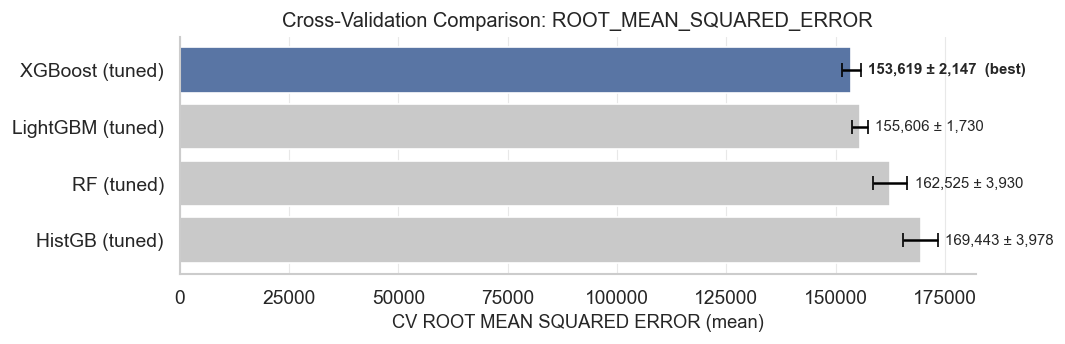

In [48]:
fig = plot_cv_comparison(tuned_cv)
plt.show()
save_figure(fig, "cv_comparison_tuned", FIG_DIR / "hyperparameter_tuning")

**Tuning findings:**

Tuning rewrote the leaderboard. The untuned round had Random Forest in front, but the boosters had far more headroom and blew past it once the grids did their work:

- XGBoost: €172.9k → €153.6k (best: 600 trees, depth 9, learning rate 0.1)
- LightGBM: €177.9k → €155.6k (best: 600 trees, 127 leaves, learning rate 0.1)
- HistGB: €178.4k → €169.4k (best: 400 iterations, unrestricted depth)
- Random Forest: €163.0k → €162.5k (essentially flat; its defaults were already close to its best)

The asymmetry is the lesson: bagging is robust out of the box but has few knobs that matter, while boosting is mediocre at defaults and excellent once the learning rate, capacity, and tree count are balanced. Both XGBoost and LightGBM chose the largest tree count in the grid (600), so a longer search might squeeze out a little more, with diminishing returns and slower fits as the price.

---
## 12. Ensemble methods


In [49]:
# Ensemble the three strongest tuned models from the CV table above. The
# members are selected from the table rather than hardcoded, so the ensemble
# follows the evidence if a different family wins after retuning.
top3 = [(name, tuned_pipelines[name]) for name in tuned_cv.index[:3]]
print(f"Ensemble members: {[name for name, _ in top3]}")

voting_reg = VotingRegressor(estimators=top3)

stacking_reg = StackingRegressor(
    estimators=top3,
    final_estimator=Ridge(alpha=1.0),
    cv=CV,
    n_jobs=-1,
)

ensemble_pipelines = {
    "Voting (avg)":          voting_reg,
    "Stacking (Ridge meta)": stacking_reg,
}
all_pipelines = {**tuned_pipelines, **ensemble_pipelines}
ensemble_cv = cv_compare(all_pipelines, X_train, y_train)
ensemble_cv

Ensemble members: ['XGBoost (tuned)', 'LightGBM (tuned)', 'RF (tuned)']


,cv_neg_root_mean_squared_error_mean,cv_neg_root_mean_squared_error_std,train_score_mean,fit_time_s
model,,,,
Stacking (Ridge meta),-150402.7336,2293.3617,-52813.5584,167.82
Voting (avg),-151236.9591,2652.8654,-55039.6880,55.95
XGBoost (tuned),-153619.2000,2146.5117,-63252.8612,8.91
LightGBM (tuned),-155606.2913,1730.4707,-56295.9462,36.02
RF (tuned),-162525.4155,3929.6638,-61627.0856,15.42
HistGB (tuned),-169443.3735,3977.5755,-138418.2292,33.15


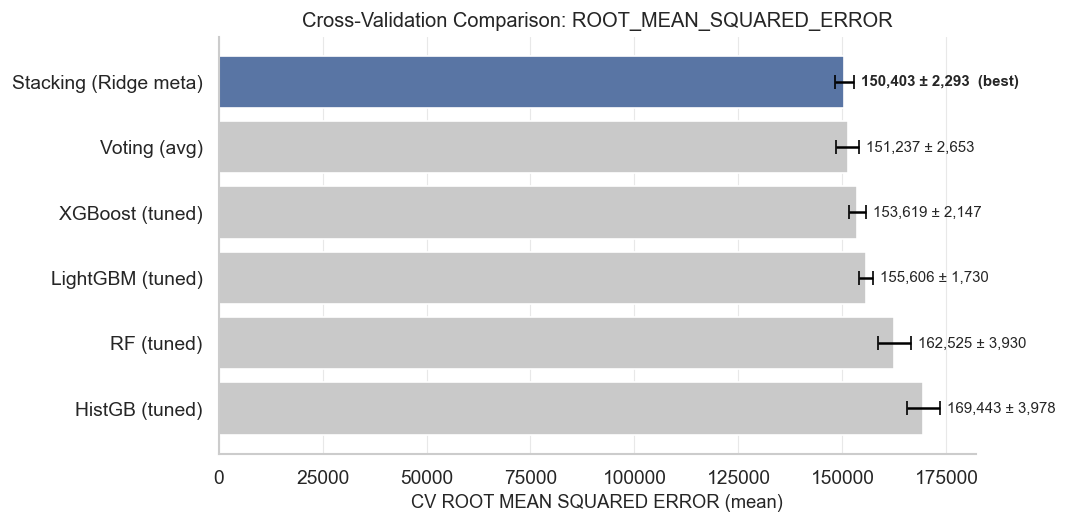

In [50]:
fig = plot_cv_comparison(ensemble_cv)
plt.show()
save_figure(fig, "cv_comparison_ensemble", FIG_DIR / "model_comparison")

**Ensemble findings:**

- VotingRegressor averages the three tuned models, and the averaging cancels out fold-specific quirks, so it tends to be more stable than any single model.
- StackingRegressor uses a Ridge meta-learner to learn how much weight to give each base model, and that pays off when the base models make different *kinds* of errors.

**Which ensemble we carry forward, and why:** stacking came out ahead on cross-validation (€150.4k vs voting's €151.2k, with the best single model at €153.6k), so the code carries it to the test set; the selection reads the CV table rather than hardcoding a name, so it follows the evidence if a rerun reorders things. The margin over voting is about 0.6%, within fold-to-fold noise (CV std around ±€2.3k), so the honest claim is that the two ensembles are statistically tied and both beat every single model. Stacking's cost is training time: roughly 168s against voting's 56s, because it refits the base models inside an internal cross-validation loop to train the meta-learner.

This section only settles the best-*scoring* model. The model we actually deploy is decided in Section 15, after the final test evaluation, because the most accurate model is not always the right one to ship.

---
## 13. Final test evaluation


In [51]:
final_models = dict(tuned_pipelines)

# Carry forward whichever ensemble won the CV comparison above.
ens_ranked = [n for n in ensemble_cv.index if n in ensemble_pipelines]
best_ensemble = ensemble_pipelines[ens_ranked[0]]
best_ensemble.fit(X_train, y_train)
final_models[f"Ensemble: {ens_ranked[0]}"] = best_ensemble
print(f"Ensemble carried to the test set: {ens_ranked[0]}")

all_metrics = {}
for name, model in final_models.items():
    all_metrics[name] = evaluate_model(model, X_test, y_test, model_name=name)

Ensemble carried to the test set: Stacking (Ridge meta)

  XGBoost (tuned): Test Set Evaluation
  RMSE            : €145,737.81
  MAE             : €74,416.34
  R²              : 0.8555
  MAPE            : 25.63%
  Residual mean   : €-1,427.93
  Residual std    : €145,736.43



  LightGBM (tuned): Test Set Evaluation
  RMSE            : €147,563.22
  MAE             : €74,267.20
  R²              : 0.8518
  MAPE            : 25.06%
  Residual mean   : €-432.38
  Residual std    : €147,568.27



  HistGB (tuned): Test Set Evaluation
  RMSE            : €161,572.56
  MAE             : €85,310.56
  R²              : 0.8224
  MAPE            : 29.61%
  Residual mean   : €-693.59
  Residual std    : €161,577.30



  RF (tuned): Test Set Evaluation
  RMSE            : €154,192.24
  MAE             : €75,389.21
  R²              : 0.8382
  MAPE            : 26.47%
  Residual mean   : €229.14
  Residual std    : €154,198.01



  Ensemble: Stacking (Ridge meta): Test Set Evaluation
  RMSE            : €142,790.30
  MAE             : €71,407.80
  R²              : 0.8613
  MAPE            : 23.22%
  Residual mean   : €-424.62
  Residual std    : €142,795.17


In [52]:
print("Final test set comparison (sorted by RMSE):")
compare_final_metrics(all_metrics)

Final test set comparison (sorted by RMSE):


,rmse,mae,r2,mape,residual_mean,residual_std
model,,,,,,
Ensemble: Stacking (Ridge meta),142790.30,71407.80,0.8613,0.2322,-424.62,142795.17
XGBoost (tuned),145737.81,74416.34,0.8555,0.2563,-1427.93,145736.43
LightGBM (tuned),147563.22,74267.20,0.8518,0.2506,-432.38,147568.27
RF (tuned),154192.24,75389.21,0.8382,0.2647,229.14,154198.01
HistGB (tuned),161572.56,85310.56,0.8224,0.2961,-693.59,161577.30


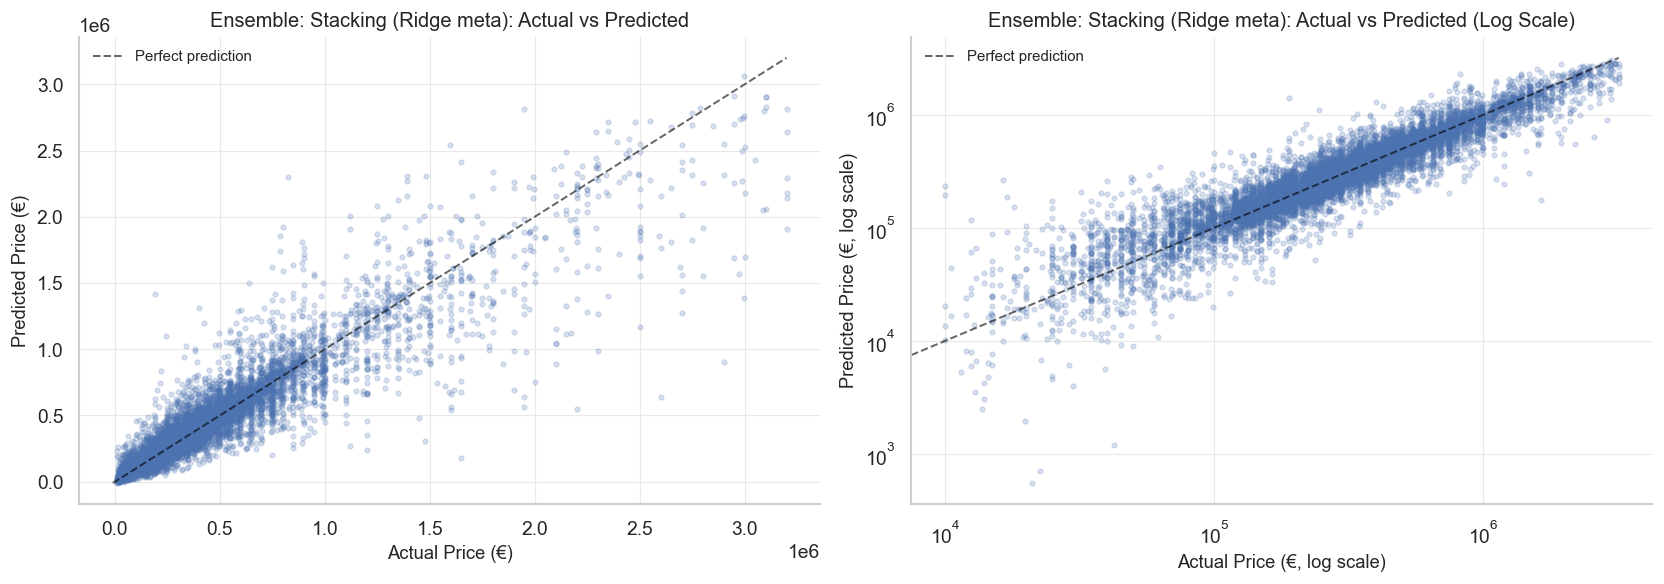

In [53]:
top_model_name = compare_final_metrics(all_metrics).index[0]
top_model      = final_models[top_model_name]
top_preds      = all_metrics[top_model_name]["y_pred"]

fig = plot_actual_vs_predicted(y_test, top_preds, top_model_name)
plt.show()
save_figure(fig, "actual_vs_predicted_top", FIG_DIR / "final_evaluation")

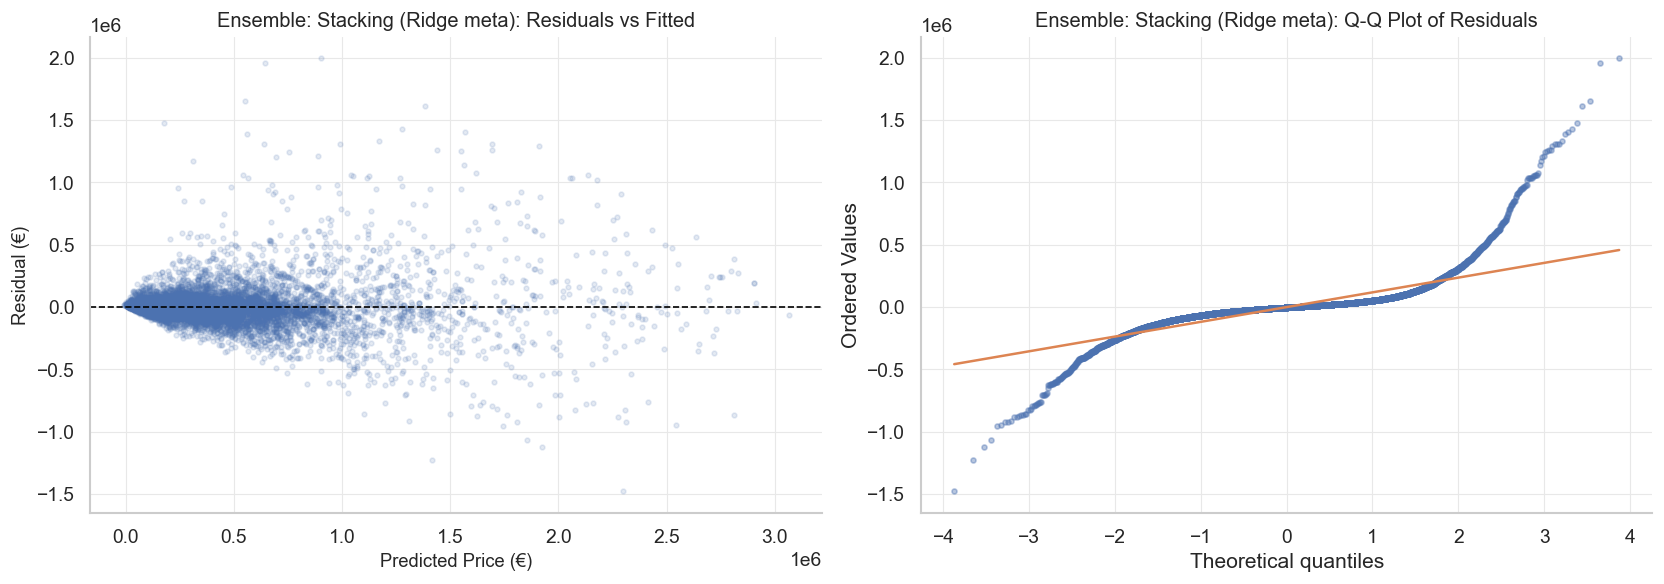

In [54]:
fig = plot_residuals(y_test, top_preds, top_model_name)
plt.show()
save_figure(fig, "residuals_top", FIG_DIR / "final_evaluation")

**Final evaluation interpretation:**

The held-out test set confirms the CV ordering. The stacking ensemble lands at €142.8k RMSE (R² 0.861), followed by XGBoost at €145.7k (0.856), LightGBM at €147.6k (0.852), Random Forest at €154.2k (0.838), and HistGB at €161.6k (0.822). Residual means sit within about €1.4k of zero for every model, so none of them is systematically biased, and MAPE runs 23-26% for the contending models (HistGB trails at 30%), which is the honest per-listing error a broker should expect.

- The actual-vs-predicted scatter is the headline plot, and points along the diagonal are accurate predictions; spread away from it shows where the model misses.
- The log-scale view tells us whether the model behaves consistently across price bands or breaks down at the high end. Very expensive listings are typically the hardest segment.
- Residual diagnostics: the residuals-vs-fitted plot checks for heteroscedasticity, and the Q-Q plot checks tail behavior. Heavy tails are normal for price data and acceptable for tree-based models, which do not assume Gaussian residuals.

### AutoML benchmark (FLAML)

A fair question after any manual model search: would an AutoML system have done better with the same data and features? FLAML gets the same preprocessed training matrix, a 3-minute search budget over the same model families (LightGBM, XGBoost, random forest, extra trees), and is evaluated on the same held-out test set. This runs after model selection is locked in, so it cannot influence any decision above; it is purely a benchmark of the manual work.

In [55]:
from flaml import AutoML
from sklearn.metrics import mean_squared_error, r2_score

X_train_mat = pre_fitted.transform(X_train).astype(float)
X_test_mat  = pre_fitted.transform(X_test).astype(float)

automl = AutoML()
automl.fit(
    X_train_mat, y_train.to_numpy(),
    task="regression", metric="rmse",
    estimator_list=["lgbm", "xgboost", "rf", "extra_tree"],
    time_budget=180, seed=RANDOM_SEED, verbose=0,
)

flaml_pred = automl.predict(X_test_mat)
flaml_rmse = float(np.sqrt(mean_squared_error(y_test, flaml_pred)))
flaml_r2   = r2_score(y_test, flaml_pred)
print(f"FLAML best estimator : {automl.best_estimator}")
print(f"FLAML best config    : {automl.best_config}")
print(f"FLAML test RMSE      : EUR {flaml_rmse:,.0f}")
print(f"FLAML test R2        : {flaml_r2:.4f}")

FLAML best estimator : xgboost
FLAML best config    : {'n_estimators': 1996, 'max_leaves': 44, 'min_child_weight': np.float64(0.2679519592529925), 'learning_rate': np.float64(0.25756071144459397), 'subsample': np.float64(0.6997614579813564), 'colsample_bylevel': 1.0, 'colsample_bytree': np.float64(0.9450862450286872), 'reg_alpha': np.float64(0.0015739669067275335), 'reg_lambda': np.float64(11.662294627260762)}
FLAML test RMSE      : EUR 149,282
FLAML test R2        : 0.8484


**AutoML benchmark reading:** FLAML spent its 3-minute budget, picked XGBoost, and landed at €149.3k test RMSE (R² 0.848). That places it behind the stacking ensemble (€142.8k), the manually tuned XGBoost (€145.7k), and tuned LightGBM (€147.6k), ahead of only the tuned forest and HistGB, all on identical features. The manual search holds up, which is reassuring rather than surprising: FLAML explores a much wider hyperparameter space but has three minutes to do it, while the manual grids encode what actually matters for this data. A larger budget would likely close the gap, so the fair conclusion is that AutoML is an excellent sanity check and a fast starting point, not a replacement for understanding the problem.

---
## 14. Error analysis and interpretation


### 14.1 SHAP and feature importance

SHAP (SHapley Additive exPlanations) breaks a single prediction into a euro contribution from each feature, so we can say *why* the model priced a property the way it did.

A few notes on the setup below:

- The explanations run on the tuned **LightGBM** model,  SHAP's `TreeExplainer` is the fast, exact explainer for gradient-boosted trees and works cleanly with it. The installed XGBoost serializes `base_score` in a format the current SHAP version cannot parse, so LightGBM is used here, which is also the model we deploy, so the explanations describe what runs in production.
- The transformed feature matrix is cast to float because the one-hot output mixes integer and float columns, and SHAP expects a uniform numeric array.

In [56]:
best_tree = lgbm_grid_search.best_estimator_
pre = best_tree.named_steps["pre"]
clf = best_tree.named_steps["clf"]

X_train_transformed = pre.transform(X_train).astype(float)
X_test_transformed  = pre.transform(X_test).astype(float)
feature_names = pre.get_feature_names_out().tolist()

explainer = shap.TreeExplainer(clf, feature_names=feature_names)
shap_values = explainer(X_test_transformed)

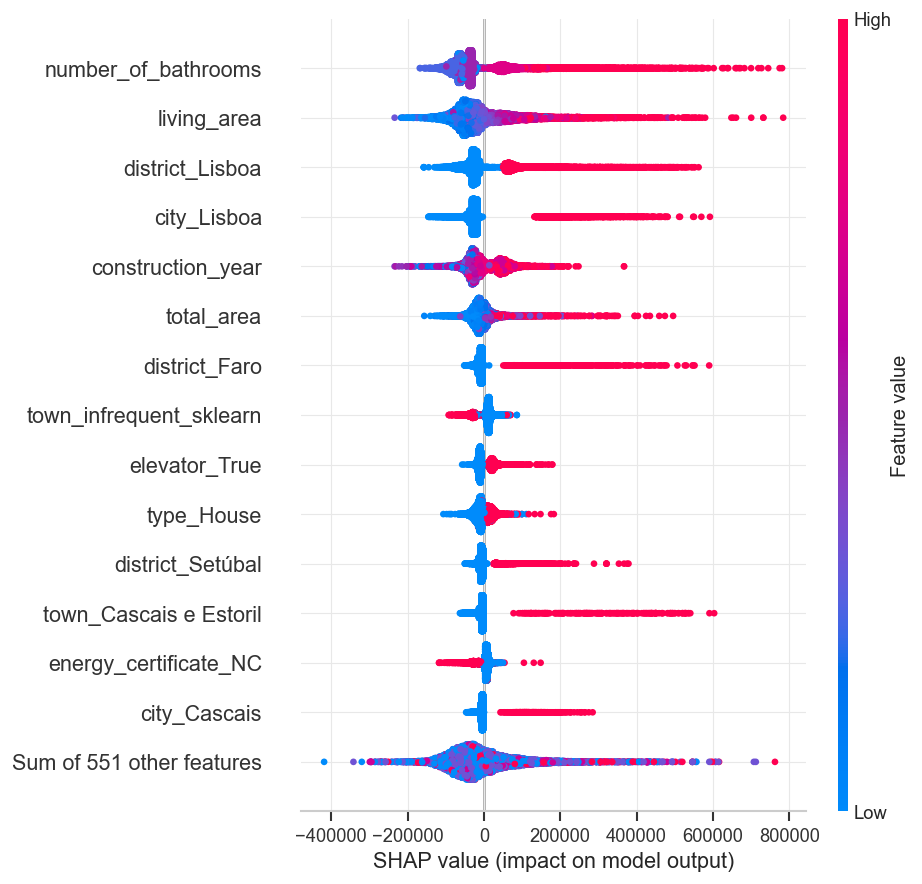

In [57]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
fig_shap = plt.gcf()
fig_shap.tight_layout()
plt.show()
save_figure(fig_shap, "shap_beeswarm", FIG_DIR / "error_analysis")

**SHAP beeswarm interpretation:**

Each dot is one test sample, and the horizontal position is the SHAP value (impact on the prediction, in euros). Color encodes the feature value (red = high, blue = low), and the features are ranked top-to-bottom by mean absolute SHAP, so the most influential drivers are at the top.

This is the global view: it tells us which features matter and in which direction.


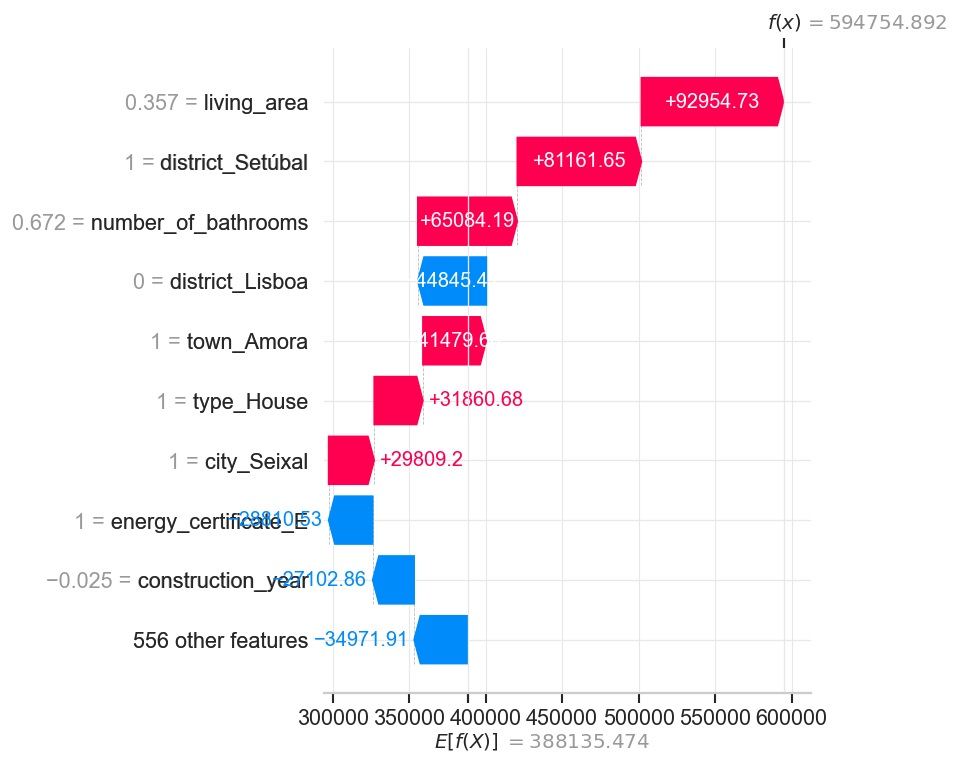

In [58]:
idx = 0
shap.plots.waterfall(shap_values[idx], show=False)
fig_wf = plt.gcf()
fig_wf.tight_layout()
plt.show()
save_figure(fig_wf, "shap_waterfall", FIG_DIR / "error_analysis")

**SHAP waterfall interpretation:**

This plot explains a single prediction. Each bar shows how one feature pushed the prediction up or down from the base value (the mean prediction across the dataset). Red bars push up, blue bars push down.

For the use case here, the per-prediction explanation is the important part. A broker is not going to call an owner because "the model says so". They need a defensible reason, and the waterfall plot gives them one: this listing looks underpriced because area X and location Y normally indicate a higher price.


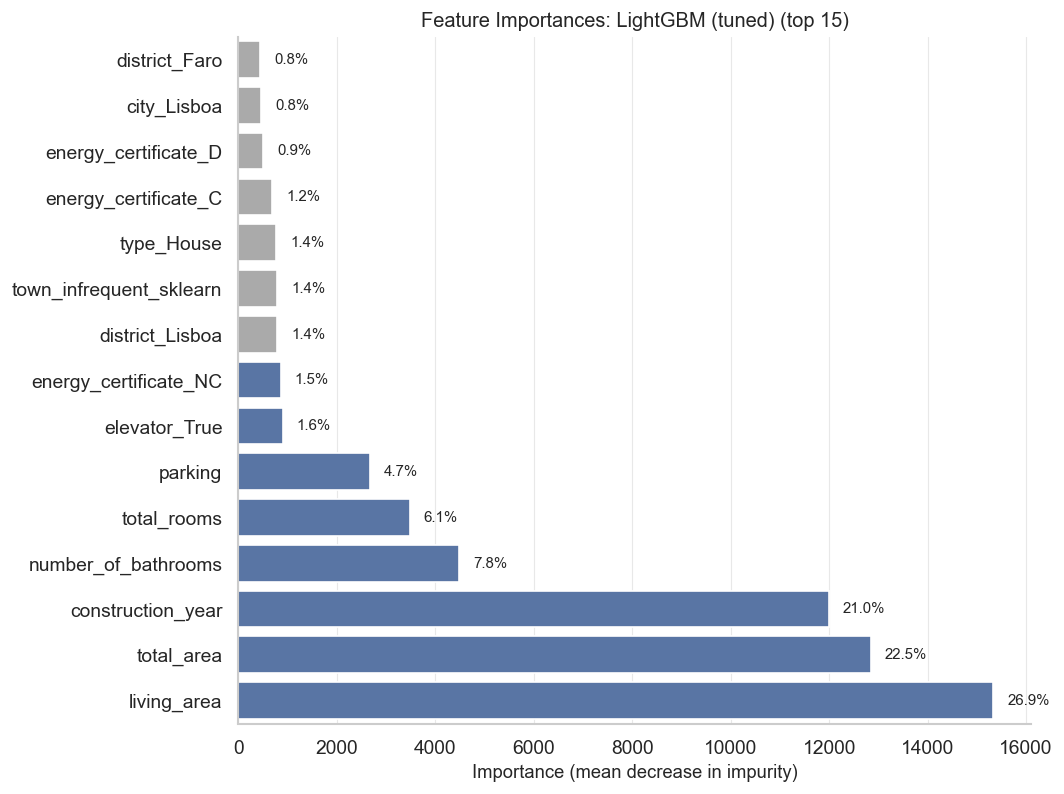

In [59]:
fig = plot_feature_importance(feature_names, clf.feature_importances_, "LightGBM (tuned)")
plt.show()
save_figure(fig, "feature_importance", FIG_DIR / "error_analysis")

### 14.2 Learning curve: overfitting check


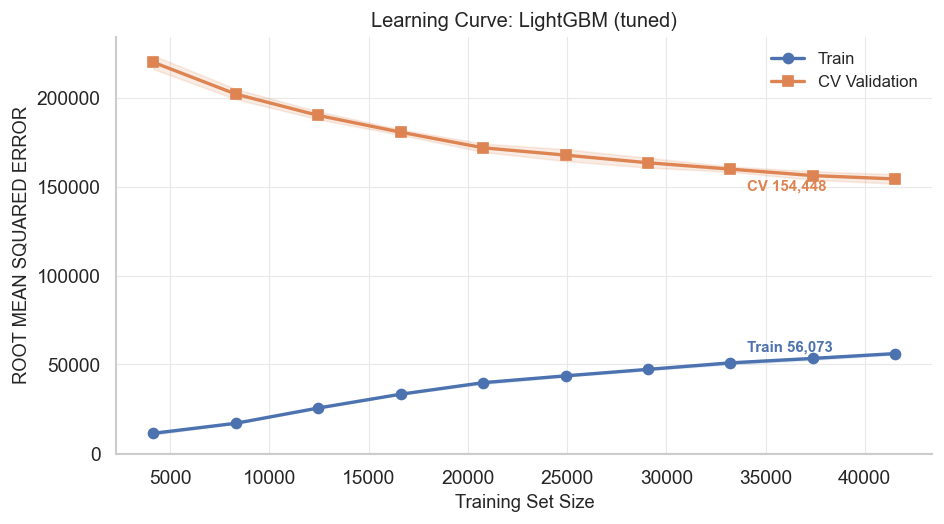

In [60]:
fig = plot_learning_curve(best_tree, X_train, y_train, "LightGBM (tuned)")
plt.show()
save_figure(fig, "learning_curve", FIG_DIR / "error_analysis")

**Learning curve findings:**

Three patterns to watch for:

- Curves that converge as training size grows, and the model has roughly enough data and is not severely overfitting.
- A persistent train-vs-validation gap, classic overfitting. Either more data, stronger regularization, or a simpler model would help.
- Both curves plateauing well before the dataset is exhausted. Diminishing returns from more rows. Better features or a more expressive model is the next lever.


---
## 15. Deployment


### Batch vs. real-time inference

| Mode | When to use | How it works |
|------|-------------|--------------|
| Batch inference | Scheduled scoring of many records (for example, a nightly scan of new listings) | Read CSV, predict all rows, write results |
| Real-time inference | Immediate prediction for a single listing (for example, when a new property is uploaded) | HTTP POST with features, instant price prediction |

The business requirement here is real-time: brokers want predictions the moment a new listing appears, so the primary deployment is a REST API. The batch script is included for backfills and ad-hoc scoring of historical data.


### Choosing the deployment model

The most accurate model is not automatically the one to deploy. For a real-time API, the size of the saved model drives cold-start latency and whether it even fits in the container's memory. Putting accuracy and size side by side (sizes measured by serializing each fitted pipeline with joblib):

| Model | Test RMSE | Test R² | Size on disk | Deployable as a small API? |
|-------|-----------|---------|--------------|----------------------------|
| Ensemble (Stacking) | €142,790 (best) | 0.861 | ~1.7 GB | No, far too large for a small container |
| XGBoost (tuned) | €145,738 | 0.856 | 7.1 MB | Yes |
| **LightGBM (tuned)** | **€147,563** | **0.852** | **8.5 MB** | **Yes, deployed** |
| Random Forest (tuned) | €154,192 | 0.838 | 848 MB | No, bulky and slow to load |

Two decisions here:

1. **Compact booster over the heavy models:** the stacking ensemble is the most accurate, but at 1.7 GB it cannot live in a lightweight serverless container, and the unrestricted-depth Random Forest has the same problem at 848 MB. LightGBM gives up about 3% RMSE against the ensemble for a model that is roughly 200x smaller and loads in milliseconds. That is the trade that actually matters.

2. **LightGBM vs XGBoost is a tie, broken on explainability:** they are within about 1.3% of each other on test RMSE (XGBoost slightly ahead) and both are single-digit megabytes. The tiebreaker is that the SHAP analysis in Section 14 runs on LightGBM, so deploying LightGBM keeps the model in production identical to the one we explained. Either would be a defensible choice.

So we deploy the tuned **LightGBM**: within noise of the best deployable model, a fraction of the ensemble's size, and consistent with the explainability work.

In [61]:
deployment_model = lgbm_grid_search.best_estimator_

model_path = Path.cwd().parent / "deployment" / "model.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(deployment_model, model_path)

size_mb = model_path.stat().st_size / 1e6
print(f"Deployment model : {type(deployment_model.named_steps['clf']).__name__}")
print(f"Saved to         : {model_path}")
print(f"Artifact size    : {size_mb:.1f} MB")

Deployment model : LGBMRegressor
Saved to         : /Users/hussein-loubani/Turing College/Module 3/Sprint 2/deployment/model.pkl
Artifact size    : 8.5 MB


### Deployment artifacts

The `deployment/` directory contains:

- `app.py`: FastAPI real-time prediction endpoint (POST `/predict`, GET `/health`). Validation mirrors the training-data sanity rules: closed vocabularies for district, property type, and energy certificate, numeric bounds with finite-number checks, and a cross-field rule that living area cannot exceed total area. CORS stays off unless a frontend origin list is provided via the `ALLOWED_ORIGINS` environment variable, so the API never ships with a wildcard policy.
- `streamlit_app.py`: a Streamlit UI for manual price estimation, with real district, city, and town inputs. Useful as a demo and for sanity-checking inputs.
- `batch_inference.py`: CLI script for bulk CSV prediction.
- `Dockerfile`: container image (Python 3.10 slim, port 8080).
- `deploy_guide.md`: walkthrough for shipping the container to Google Cloud Run.

To run the API locally:

```bash
cd deployment/
uvicorn app:app --reload --port 8080
# Then visit http://localhost:8080/docs for the interactive Swagger UI.
```


### Batch inference demo

Real-time serving (the API above) handles one listing at a time. Batch inference is the offline counterpart: score a whole file of listings in a single pass, for example a nightly re-scoring of the catalog. The cell below scores five held-out listings at once. The standalone command-line version is `deployment/batch_inference.py`, which reads an input CSV and writes the same predictions to an output CSV.

In [62]:
batch = test_df[ALL_FEATURES].head(5).copy()
batch["predicted_price"] = deployment_model.predict(batch).round(2)
batch[["district", "type", "total_area", "energy_certificate", "predicted_price"]]

,district,type,total_area,energy_certificate,predicted_price
0,Setúbal,House,450.0,E,594753.95
1,Bragança,Apartment,228.0,B-,343794.42
2,Coimbra,House,94.0,NC,54437.67
3,Porto,Apartment,102.0,NC,483757.99
4,Santarém,House,250.0,NC,268872.59


---
## 16. Dashboard


In [63]:
from portugal_housing.plots import dashboard_portugal_housing

dashboard_fig = dashboard_portugal_housing(
    df=df,
    cv_results=ensemble_cv,
    final_metrics=all_metrics,
    final_models=final_models,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
    out_path=str(FIG_DIR / "dashboard_portugal_housing.html"),
)
dashboard_fig.show()

---
## 17. Conclusion, limitations, and recommendations

### Conclusion

Location and size do most of the work, and the single biggest improvement in this version came from taking location seriously: keeping city and town as pooled one-hot features, instead of dropping them for cardinality, lifted held-out R² from about 0.72 to 0.85 and cut RMSE by roughly €50k. District, `total_area`, and `living_area` remain the other first-order drivers, and the energy certificate adds a real premium on top, which the ANOVA in Section 7 confirms is not noise.

Two modeling results are worth calling out. First, the untuned round and the tuned round disagree: Random Forest led with default settings, but the boosters had far more tuning headroom, and tuned XGBoost (€145.7k test RMSE) and the stacking ensemble (€142.8k, R² 0.861) finished on top. Second, the two reflexes the data refused to reward were both tested rather than assumed: the log-price target made euro-scale error about 7% worse, and FLAML's AutoML search with the same features and a 3-minute budget came in behind the manual grids (€149.3k vs €145.7k).

I deployed the tuned LightGBM rather than the test-set winner: at €147.6k RMSE it gives up about 3% against the stacking ensemble, but it is a single 8.5 MB artifact that loads in milliseconds, and it is the exact model the SHAP analysis explains.

The honest headline is R² around 0.85 with a MAPE of about 25%. The model ranks listings well and is genuinely useful for flagging underpriced ones, but a per-listing error of a quarter of the asking price means it is a screening tool, not a precise valuation tool.

### Limitations

- Asking price is not sale price. We predict what sellers list, not what buyers pay.
- The data is scraped, so duplicates, entry errors, and inconsistent formatting are baked in. Cleaning catches the obvious cases, not the subtle ones.
- Half the columns were unusable (over 50% missing). Floor, lot size, and bedroom count would likely help if they were collected properly.
- Towns below the encoder's frequency threshold pool into a shared bucket, so the finest-grained location signal is blunted exactly where listings are scarcest.
- The model is scoped to residential listings. Land, offices, and commercial property need their own model.
- There is no time dimension. Interest rates and seasonality move prices and are not in the data.

### Recommendations

- Return prediction intervals, not single numbers. "€180k-€240k with 90% confidence" tells a broker more than one figure, especially at the high end where the model is least sure.
- Add drift monitoring and a retraining pipeline so the model is rebuilt as new listings arrive.
- Enrich the features: interest rates, transport access, population density, anything that sharpens the location signal further.
- Try target encoding for town as an alternative to pooled one-hot. It would give every town its own signal, at the cost of more careful leakage control.